In [1]:
# from os import path
# import networkx as nx
# from itertools import combinations
# from sklearn.metrics.pairwise import cosine_similarity
# import pickle
# import random
# from torch_geometric.loader import DataLoader
# from clotho.settings import PROJECT_ROOT
# from clotho.dataset.extract.cloudburst_connection import (
#     get_masterminds,
#     get_train_masterminds,
#     get_scored_signals,
#     get_train_scored_signals,
# )

# from clotho.dataset.preprocess.process import (
#     aggregate_data,
#     assign_event_ids,
#     process_dataframe,
#     features_engineer,
#     get_graphs,
# )

# from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# # from clotho.dataset.gnn_dataset_preparation import (
# #     graph_features,
# #     combine_features,
# #     prepare_data,
# # )

# from os import path
# import pickle
# import pandas as pd
# import networkx as nx
# import torch
# from torch_geometric.data import Data
# from torch_geometric.loader import DataLoader
# from clotho.dataset.extract.cloudburst_connection import (
#     get_scored_signals,
#     get_train_scored_signals,
# )

# from clotho.settings import PROJECT_ROOT
# from clotho.dataset.preprocess.process import (
#     aggregate_data,
#     assign_event_ids,
#     process_dataframe,
#     features_engineer,
#     get_graphs,
# )

# from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from itertools import combinations
# from sklearn.metrics.pairwise import cosine_similarity
# from clotho.dataset.extract.cloudburst_connection import get_direct_link
# from itertools import combinations
# from sklearn.metrics.pairwise import cosine_similarity
# def calculate_effsize_efficiency(G, ego):
#     # Get the ego network
#     ego_net = nx.ego_graph(G, ego, undirected=False)
#     # Get alters in the ego network (excluding ego)
#     alters = set(ego_net.nodes()) - {ego}
#     num_alters = len(alters)
#     # Inside your calculate_effsize_efficiency function:
#     avg_degree = 0  # Default to 0
#     if num_alters > 0:
#         avg_degree = (
#             sum(
#                 ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
#                 for n in alters
#             )
#             / num_alters
#         )
#     # Calculate effective size
#     eff_size = num_alters - avg_degree
#     # Calculate efficiency
#     efficiency = eff_size / num_alters if num_alters > 0 else 0
#     return eff_size, efficiency

# def out_ego_graph(G, node, radius=1):
#     """
#     Extract the out-ego network of a specified node in a directed graph.
#     """
#     # Extract the out-ego network
#     out_ego = nx.ego_graph(G, node, radius=radius)
#     return out_ego

# def in_ego_graph(G, node, radius=1):
#     """
#     Extract the in-ego network of a specified node in a directed graph.
#     """
#     # Reverse the graph
#     G_reverse = G.reverse(copy=True)
#     # Extract the in-ego network
#     in_ego = nx.ego_graph(G_reverse, node, radius=radius)
#     return in_ego

# def graph_features(gs):
#     dfs = {}
#     # Looping through each key in the scores dictionary
#     for key in gs.keys():
#         # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
#         node_ids = []
#         in_ratios = []
#         out_ratios = []
#         out_nodes = []
#         eff_sizes = []
#         efficiencies = []
#         density = []
#         clustering_coeffs = []
#         for i in gs[key].nodes():
#             node_id = i
#             node_ids.append(node_id)
#             # Calculating the in-ego ratio
#             inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
#             in_ratios.append(inn)
#             # Calculating the out-ego ratio
#             outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
#             out_ratios.append(outt)
#             out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
#             # Calculate the density of the ego network
#             den = nx.density(out_ego_graph(gs[key], node_id))
#             density.append(den)
#             eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
#             eff_sizes.append(eff_size)
#             efficiencies.append(efficiency)
#             # Calculate clustering coefficient for the node
#             clustering_coeff = nx.clustering(gs[key], node_id)
#             clustering_coeffs.append(clustering_coeff)
#         # Creating a DataFrame for each key and storing it in the dfs dictionary
#         dfs[key] = pd.DataFrame(
#             {
#                 "telegram_chat_id": node_ids,
#                 "in_ratio": in_ratios,
#                 "out_ratio": out_ratios,
#                 "out_nodes": out_nodes,
#                 "eff_size": eff_sizes,
#                 "efficiency": efficiencies,
#                 "density": density,
#                 "clustering_coeff": clustering_coeffs,
#             }
#         )
#     return dfs

# def combine_features(market_features, graph_features):
#     combined_data = {}
#     for key in market_features.keys():
#         # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
#         if (
#             key in graph_features
#             and "telegram_chat_id" in market_features[key].columns
#             and "telegram_chat_id" in graph_features[key].columns
#         ):
#             # Perform an inner join on 'telegram_chat_id'
#             combined_df = pd.merge(
#                 market_features[key],
#                 graph_features[key],
#                 on="telegram_chat_id",
#                 how="inner",
#             )
#         else:
#             # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
#             combined_df = pd.DataFrame()
#         combined_data[key] = combined_df
#     return combined_data

# def prepare_data(graphs, features, label_mapping):

#     prepared_data = []
#     for key, graph in graphs.items():
#         # Extract features for nodes present in the graph
#         features_buffer = features[key]
#         features_buffer = features_buffer[
#             features_buffer["telegram_chat_id"].isin(graph.nodes)
#         ]
#         # Specify feature columns and normalize them
#         feature_columns = [
#             "average_increase_percentage",
#             "number_of_signals",
#             # "average_speed",
#             # "sum_targets_achieved",
#             # "rating",
#             # "in_ratio",
#             # "out_ratio",
#             # "eff_size",
#             # "efficiency",
#         ]
#         features_to_process = features_buffer[feature_columns]
#         normalized_features = (
#             features_to_process - features_to_process.mean()
#         ) / features_to_process.std()
#         nan_columns = normalized_features.columns[
#             normalized_features.isnull().any()
#         ].tolist()
#         if nan_columns:
#             print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
#         node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
#         # Map node IDs to indices
#         id_to_index = {
#             telegram_chat_id: index
#             for index, telegram_chat_id in enumerate(
#                 features_buffer["telegram_chat_id"]
#             )
#         }
#         # Initialize lists for edge index and weights
#         edge_index_list = []
#         edge_weight_list = []
#         features_df = features_buffer.set_index("telegram_chat_id")
#         # c = features_df
#         features_df = features_df[feature_columns].dropna()
#         # cc = features_df
#         # features_df = features_df.dropna(inplace=True)
#         # ccc = features_df
#         # Calculate cosine similarity for each pair of rows
#         print(key)
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)
#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity
#         # Populate edge index and weights
#         for (source_node, target_node), weight in similarities.items():
#             source = id_to_index.get(source_node)
#             target = id_to_index.get(target_node)
#             if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
#                 edge_index_list.append([source, target])
#                 edge_weight_list.append(weight)
#         # Convert lists to PyTorch tensors
#         edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
#         edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
#         # Populate the lists
#         num_labels = 3
#         # # Prepare labels
#         # labels = [
#         #     label_mapping[key].get(node_id, 0)
#         #     for node_id in features_buffer["telegram_chat_id"]
#         # ]
#         # labels = torch.tensor(labels, dtype=torch.long)
#         # # Create a Data object
#         # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
#         # Prepare labels
#         labels = []
#         for node_id in features_buffer["telegram_chat_id"]:
#             node_labels = label_mapping[key].get(node_id, 0)
#             if not isinstance(node_labels, list):
#                 node_labels = [node_labels]  # Convert to list for consistency
#             # Convert to one-hot encoded format
#             label_vector = [0] * num_labels
#             for label in node_labels:
#                 if label < num_labels:
#                     label_vector[label] = 1
#             labels.append(label_vector)
#         # Convert list of labels to a tensor
#         labels_tensor = torch.tensor(labels, dtype=torch.float)
#         # Create a Data object
#         data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
#         prepared_data.append(data)
#     # prepared_data = []
#     # for key, graph in graphs.items():
#     #     # Extract features for nodes present in the graph
#     #     features_buffer = features[key]
#     #     features_buffer = features_buffer[
#     #         features_buffer["telegram_chat_id"].isin(graph.nodes)
#     #     ]
#     #     # Specify feature columns and normalize them
#     #     feature_columns = [
#     #         "average_increase_percentage",
#     #         "number_of_signals",
#     #         # "average_speed",
#     #         # "sum_targets_achieved",
#     #         # "rating",
#     #         # "in_ratio",
#     #         # "out_ratio",
#     #         # "eff_size",
#     #         # "efficiency",
#     #     ]
#     #     features_to_process = features_buffer[feature_columns]
#     #     normalized_features = (
#     #         features_to_process - features_to_process.mean()
#     #     ) / features_to_process.std()
#     #     nan_columns = normalized_features.columns[
#     #         normalized_features.isnull().any()
#     #     ].tolist()
#     #     if nan_columns:
#     #         print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
#     #     node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
#     #     # Map node IDs to indices
#     #     id_to_index = {
#     #         telegram_chat_id: index
#     #         for index, telegram_chat_id in enumerate(
#     #             features_buffer["telegram_chat_id"]
#     #         )
#     #     }
#     #     # Initialize lists for edge index and weights
#     #     edge_index_list = []
#     #     edge_weight_list = []
#     #     features_df = features_buffer.set_index("telegram_chat_id")
#     #     features_df = features_df[feature_columns]
#     #     # Calculate cosine similarity for each pair of rows
#     #     print(key)
#     #     similarities = {}
#     #     for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#     #         fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#     #         fj = features_df.loc[chat_id_2].values.reshape(1, -1)
#     #         similarity = cosine_similarity(fi, fj)[0][0]
#     #         similarities[(chat_id_1, chat_id_2)] = similarity
#     #     # Populate edge index and weights
#     #     for (source_node, target_node), weight in similarities.items():
#     #         source = id_to_index.get(source_node)
#     #         target = id_to_index.get(target_node)
#     #         if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
#     #             edge_index_list.append([source, target])
#     #             edge_weight_list.append(weight)
#     #     # Convert lists to PyTorch tensors
#     #     edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
#     #     edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
#     #     # Populate the lists
#     #     num_labels = 3
#     #     # # Prepare labels
#     #     # labels = [
#     #     #     label_mapping[key].get(node_id, 0)
#     #     #     for node_id in features_buffer["telegram_chat_id"]
#     #     # ]
#     #     # labels = torch.tensor(labels, dtype=torch.long)
#     #     # # Create a Data object
#     #     # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
#     #     # Prepare labels
#     #     labels = []
#     #     for node_id in features_buffer["telegram_chat_id"]:
#     #         node_labels = label_mapping[key].get(node_id, 0)
#     #         if not isinstance(node_labels, list):
#     #             node_labels = [node_labels]  # Convert to list for consistency
#     #         # Convert to one-hot encoded format
#     #         label_vector = [0] * num_labels
#     #         for label in node_labels:
#     #             if label < num_labels:
#     #                 label_vector[label] = 1
#     #         labels.append(label_vector)
#     #     # Convert list of labels to a tensor
#     #     labels_tensor = torch.tensor(labels, dtype=torch.float)
#     #     # Create a Data object
#     #     data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
#     #     prepared_data.append(data)
#     return prepared_data

# def get_new_data_loader():
#     train_signals = get_train_scored_signals()
#     processed_train_signals = process_dataframe(train_signals)
#     ided_train_signals = assign_event_ids(processed_train_signals)
#     train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
#     train_gs, results, As, P_dict = get_graphs(
#         train_cascade, train_no_nodes, train_id_mapping
#     )
#     train_f = graph_features(train_gs)
#     train_market_features = features_engineer(processed_train_signals)
#     train_c = combine_features(train_market_features, train_f)
#     # train_ngs = get_similar_graph(train_c)
#     train_label_mapping = create_label_mapping(3, "train")
#     print("train_data_prepared")

#     signals = get_scored_signals()
#     processed_signals = process_dataframe(signals)
#     ided_signals = assign_event_ids(processed_signals)
#     cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
#     gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
#     f = graph_features(gs)
#     market_features = features_engineer(processed_signals)
#     c = combine_features(market_features, f)
#     # ngs = get_similar_graph(c)
#     label_mapping = create_label_mapping(3, "test")

#     # Prepare data for training and testing sets
#     train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
#     test_data = prepare_data(gs, market_features, label_mapping)

#     train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
#     test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


#     return train_loader, test_loader


# if __name__ == "__main__":
#     a, b = get_new_data_loader()


from os import path
import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping

# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )

from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity


def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)
    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )
    # Calculate effective size
    eff_size = num_alters - avg_degree
    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0
    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}
    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []
        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)
            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)
            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)
            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)
            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)
        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )
    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}
    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()
        combined_data[key] = combined_df
    return combined_data


def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        # c = features_df
        features_df = features_df[feature_columns].dropna()
        # cc = features_df
        # features_df = features_df.dropna(inplace=True)
        # ccc = features_df
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )
        prepared_data.append(data)
    # prepared_data = []
    # for key, graph in graphs.items():
    #     # Extract features for nodes present in the graph
    #     features_buffer = features[key]
    #     features_buffer = features_buffer[
    #         features_buffer["telegram_chat_id"].isin(graph.nodes)
    #     ]
    #     # Specify feature columns and normalize them
    #     feature_columns = [
    #         "average_increase_percentage",
    #         "number_of_signals",
    #         # "average_speed",
    #         # "sum_targets_achieved",
    #         # "rating",
    #         # "in_ratio",
    #         # "out_ratio",
    #         # "eff_size",
    #         # "efficiency",
    #     ]
    #     features_to_process = features_buffer[feature_columns]
    #     normalized_features = (
    #         features_to_process - features_to_process.mean()
    #     ) / features_to_process.std()
    #     nan_columns = normalized_features.columns[
    #         normalized_features.isnull().any()
    #     ].tolist()
    #     if nan_columns:
    #         print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
    #     node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
    #     # Map node IDs to indices
    #     id_to_index = {
    #         telegram_chat_id: index
    #         for index, telegram_chat_id in enumerate(
    #             features_buffer["telegram_chat_id"]
    #         )
    #     }
    #     # Initialize lists for edge index and weights
    #     edge_index_list = []
    #     edge_weight_list = []
    #     features_df = features_buffer.set_index("telegram_chat_id")
    #     features_df = features_df[feature_columns]
    #     # Calculate cosine similarity for each pair of rows
    #     print(key)
    #     similarities = {}
    #     for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
    #         fi = features_df.loc[chat_id_1].values.reshape(1, -1)
    #         fj = features_df.loc[chat_id_2].values.reshape(1, -1)
    #         similarity = cosine_similarity(fi, fj)[0][0]
    #         similarities[(chat_id_1, chat_id_2)] = similarity
    #     # Populate edge index and weights
    #     for (source_node, target_node), weight in similarities.items():
    #         source = id_to_index.get(source_node)
    #         target = id_to_index.get(target_node)
    #         if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
    #             edge_index_list.append([source, target])
    #             edge_weight_list.append(weight)
    #     # Convert lists to PyTorch tensors
    #     edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    #     edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
    #     # Populate the lists
    #     num_labels = 3
    #     # # Prepare labels
    #     # labels = [
    #     #     label_mapping[key].get(node_id, 0)
    #     #     for node_id in features_buffer["telegram_chat_id"]
    #     # ]
    #     # labels = torch.tensor(labels, dtype=torch.long)
    #     # # Create a Data object
    #     # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
    #     # Prepare labels
    #     labels = []
    #     for node_id in features_buffer["telegram_chat_id"]:
    #         node_labels = label_mapping[key].get(node_id, 0)
    #         if not isinstance(node_labels, list):
    #             node_labels = [node_labels]  # Convert to list for consistency
    #         # Convert to one-hot encoded format
    #         label_vector = [0] * num_labels
    #         for label in node_labels:
    #             if label < num_labels:
    #                 label_vector[label] = 1
    #         labels.append(label_vector)
    #     # Convert list of labels to a tensor
    #     labels_tensor = torch.tensor(labels, dtype=torch.float)
    #     # Create a Data object
    #     data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
    #     prepared_data.append(data)
    return prepared_data


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

In [2]:
a

In [3]:
b

In [4]:
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

In [5]:
    graphs = train_gs
    features = train_market_features
    label_mapping = train_label_mapping

    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        # c = features_df
        features_df = features_df[feature_columns].dropna()
        # cc = features_df
        # features_df = features_df.dropna(inplace=True)
        # ccc = features_df
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )
        prepared_data.append(data)

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL


In [6]:
    graphs = train_gs
    features = train_market_features
    label_mapping = train_label_mapping

    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        # c = features_df
        print(features_df[feature_columns].isna())

        # features_df = features_df[feature_columns].dropna()
        # cc = features_df
        # features_df = features_df.dropna(inplace=True)
        # ccc = features_df
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )
        prepared_data.append(data)

                  average_increase_percentage  number_of_signals
telegram_chat_id                                                
5                                       False              False
8                                       False              False
19                                      False              False
49                                      False              False
66                                      False              False
71                                      False              False
78                                      False              False
2078                                    False              False
1INCH
                  average_increase_percentage  number_of_signals
telegram_chat_id                                                
5                                       False              False
66                                      False              False
78                                      False              False
79                 

Epoch 1/100, Loss: 0.6628033181251083
Epoch 2/100, Loss: 0.6581336340522239
Epoch 3/100, Loss: 0.6645674145682741
Epoch 4/100, Loss: 0.6490789092048097
Epoch 5/100, Loss: 0.6460938741818317
Epoch 6/100, Loss: 0.6509325191460921
Epoch 7/100, Loss: 0.6500022376769156
Epoch 8/100, Loss: 0.6418373678599932
Epoch 9/100, Loss: 0.6375235373473299
Epoch 10/100, Loss: 0.6374581242134558
Epoch 11/100, Loss: 0.6341581700256517
Epoch 12/100, Loss: 0.6324580562048854
Epoch 13/100, Loss: 0.63389301662287
Epoch 14/100, Loss: 0.6302372953180451
Epoch 15/100, Loss: 0.6325458248675857
Epoch 16/100, Loss: 0.6285817183513009
Epoch 17/100, Loss: 0.6327713487556627
Epoch 18/100, Loss: 0.6303094740730623
Epoch 19/100, Loss: 0.6279787953058
Epoch 20/100, Loss: 0.6329799223670644
Epoch 21/100, Loss: 0.6210190192770563
Epoch 22/100, Loss: 0.6289051170177882
Epoch 23/100, Loss: 0.6204475664960746
Epoch 24/100, Loss: 0.6226666663562396
Epoch 25/100, Loss: 0.6229483621884446
Epoch 26/100, Loss: 0.6207109340646649


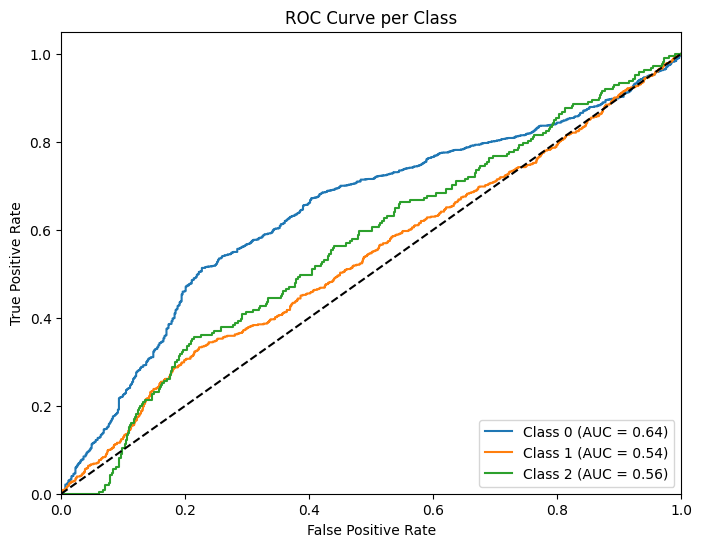

ValueError: Input contains NaN.

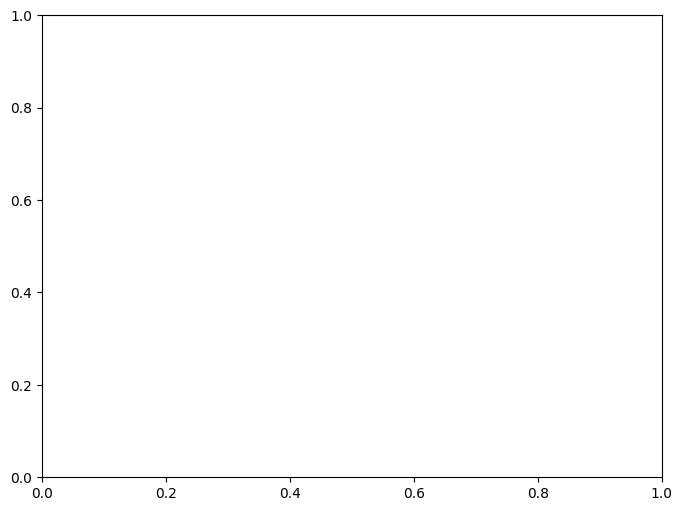

In [7]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    train()

def calculate_roc(loader):
    model.eval()
    all_preds = []
    all_labels = []
    for data in loader:
        data = data.to(device)
        out = torch.sigmoid(model(data.x, data.edge_index))
        all_preds.append(out.detach().cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(num_classes):
        # Handle NaN values in predictions and labels
        valid_idx = ~np.isnan(all_preds[:, i]) & ~np.isnan(all_labels[:, i])
        if np.sum(valid_idx) == 0:  # Skip this class if all are NaN
            print(f"Skipping Class {i} due to NaN values")
            continue
        fpr, tpr, _ = roc_curve(all_labels[valid_idx, i], all_preds[valid_idx, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve per Class')
    ax.legend(loc="lower right")
    plt.show()

def calculate_precision_recall(loader):
    model.eval()
    all_preds = []
    all_labels = []
    for data in loader:
        data = data.to(device)
        out = torch.sigmoid(model(data.x, data.edge_index))
        all_preds.append(out.detach().cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(all_labels[:, i], all_preds[:, i])
        ap = average_precision_score(all_labels[:, i], all_preds[:, i])
        ax.plot(recall, precision, label=f'Class {i} (AP = {ap:.2f})')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve per Class')
    ax.legend(loc="best")
    plt.show()

# Example usage
num_features = 2  # Adjust based on your dataset
num_classes = 3   # Adjust based on your dataset
model = GCN(num_features, 16, num_classes).to(device)

# Assuming train_loader and test_loader are defined and loaded with your dataset
run_experiment(model, a, b, num_epochs=100)

# After training, visualize the results
calculate_roc(b)
calculate_precision_recall(b)


In [8]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x



train_loader = a
test_loader = b

# Assuming the additional metrics calculation functions are defined in your script as given
# Updated Metrics Calculation Functions
def calculate_accuracy(labels, preds):
    return accuracy_score(labels, preds)


def calculate_precision(labels, preds):
    return precision_score(labels, preds, average="macro", zero_division=0)


def calculate_recall(labels, preds):
    return recall_score(labels, preds, average="macro", zero_division=0)


def calculate_f1_score(labels, preds):
    return f1_score(labels, preds, average="macro", zero_division=0)

@torch.no_grad()
def compute_metrics(probs, labels):
    # Assuming probs and labels are already in numpy array format
    preds = (probs > 0.5).astype(int)  # Convert probabilities to binary predictions

    # Calculating metrics for each label
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Calculate additional metrics if needed here
    # ...

    return accuracy, precision, recall, f1

def run_experiment(model, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                if torch.isnan(output).any() or torch.isinf(output).any():
                    print("NaN or Inf in model output")
                    continue
                loss = loss_op(output, data.y.float())
                if torch.isnan(loss) or torch.isinf(loss):
                    print("NaN or Inf in loss")
                    continue
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader.dataset)}")

    train()

    probs, labels = compute_metrics(model, test_loader)
    return model, probs, labels

num_features = 2  # Adjust based on your dataset
num_classes = 3   # Adjust based on your dataset
model = GCN(num_features, 16, num_classes)

# Run the experiment and evaluate
model, probs, labels = run_experiment(model, 100)
metrics = compute_metrics(probs, labels)

print("Metrics:", metrics)


Epoch 1/100, Loss: 0.7153355936977744
Epoch 2/100, Loss: 0.711242766999408
Epoch 3/100, Loss: 0.704831541243179
Epoch 4/100, Loss: 0.6955382833823315
Epoch 5/100, Loss: 0.6897893630338637
Epoch 6/100, Loss: 0.6859565624215985
Epoch 7/100, Loss: 0.6803036588990228
Epoch 8/100, Loss: 0.6726915437872238
Epoch 9/100, Loss: 0.6646907243939394
Epoch 10/100, Loss: 0.6622099682112426
Epoch 11/100, Loss: 0.6602559972204556
Epoch 12/100, Loss: 0.6597475995674976
Epoch 13/100, Loss: 0.648510948070505
Epoch 14/100, Loss: 0.6473749306320485
Epoch 15/100, Loss: 0.6425052319771677
Epoch 16/100, Loss: 0.6382266757237977
Epoch 17/100, Loss: 0.6399188929170535
Epoch 18/100, Loss: 0.6341683811904317
Epoch 19/100, Loss: 0.6320953005255915
Epoch 20/100, Loss: 0.6306239934586688
Epoch 21/100, Loss: 0.6261151915426413
Epoch 22/100, Loss: 0.632145889226903
Epoch 23/100, Loss: 0.6244095608345053
Epoch 24/100, Loss: 0.6203879732124055
Epoch 25/100, Loss: 0.6199392132996195
Epoch 26/100, Loss: 0.6230585769395143

TypeError: '>' not supported between instances of 'GCN' and 'float'

In [9]:
@torch.no_grad()
def test(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(torch.sigmoid(out).cpu())  # Convert logits to probabilities
        all_labels.append(data.y.cpu())
    return torch.cat(all_probs, dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()

def run_experiment(model, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader.dataset)}")

    train()

    # Compute test probabilities and labels
    probs, labels = test(model, test_loader)

    # Now correctly use compute_metrics with probabilities and labels
    accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence = compute_metrics(probs, labels)

    return model, accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence

# Corrected compute_metrics to handle multi-label predictions
@torch.no_grad()
def compute_metrics(probs, labels):
    preds = (probs > 0.5)  # Convert probabilities to binary predictions for multi-label

    # Adjust metrics calculation to handle multi-label scenario
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Additional metrics can be calculated here if needed

    return accuracy, precision, recall, f1  # Return other metrics as needed

# Run the experiment and evaluate
model = GCN(num_features, 16, num_classes)
model, accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence = run_experiment(model, 100)

print(f"Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}")
# Print additional metrics as needed


Epoch 1/100, Loss: 0.7104732861834995
Epoch 2/100, Loss: 0.7054667484365116
Epoch 3/100, Loss: 0.6971289189480945
Epoch 4/100, Loss: 0.6869784384471935
Epoch 5/100, Loss: 0.6812506673744371
Epoch 6/100, Loss: 0.6694017683274179
Epoch 7/100, Loss: 0.6703560075707199
Epoch 8/100, Loss: 0.6615949585951494
Epoch 9/100, Loss: 0.6648946170648817
Epoch 10/100, Loss: 0.6551738083362579
Epoch 11/100, Loss: 0.6531024392467836
Epoch 12/100, Loss: 0.6460396291801284
Epoch 13/100, Loss: 0.6403711159914238
Epoch 14/100, Loss: 0.6355139323361012
Epoch 15/100, Loss: 0.6325580100657532
Epoch 16/100, Loss: 0.6318081301220214
Epoch 17/100, Loss: 0.6338157550076753
Epoch 18/100, Loss: 0.6259339631262405
Epoch 19/100, Loss: 0.6250826828387561
Epoch 20/100, Loss: 0.6206409254456093
Epoch 21/100, Loss: 0.6197153196479734
Epoch 22/100, Loss: 0.6183595840114257
Epoch 23/100, Loss: 0.6176574297702115
Epoch 24/100, Loss: 0.6120875074389232
Epoch 25/100, Loss: 0.6162194423583331
Epoch 26/100, Loss: 0.615930066418

ValueError: not enough values to unpack (expected 8, got 4)

In [10]:
@torch.no_grad()
def test(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(torch.sigmoid(out).cpu())  # Convert logits to probabilities
        all_labels.append(data.y.cpu())
    return torch.cat(all_probs, dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()

def run_experiment(model, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader.dataset)}")

    train()

    # Compute test probabilities and labels
    probs, labels = test(model, test_loader)

    # Now correctly use compute_metrics with probabilities and labels
    accuracy, precision, recall, f1= compute_metrics(probs, labels)

    return model, accuracy, precision, recall, f1

# Corrected compute_metrics to handle multi-label predictions
@torch.no_grad()
def compute_metrics(probs, labels):
    preds = (probs > 0.5)  # Convert probabilities to binary predictions for multi-label

    # Adjust metrics calculation to handle multi-label scenario
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Additional metrics can be calculated here if needed

    return accuracy, precision, recall, f1  # Return other metrics as needed

# Run the experiment and evaluate
model = GCN(num_features, 16, num_classes)
model, accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence = run_experiment(model, 100)

print(f"Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}")
# Print additional metrics as needed


Epoch 1/100, Loss: 0.6718991481138198
Epoch 2/100, Loss: 0.6664047904765409
Epoch 3/100, Loss: 0.6660666523388078
Epoch 4/100, Loss: 0.6549925593381428
Epoch 5/100, Loss: 0.6557250159550767
Epoch 6/100, Loss: 0.654863087511853
Epoch 7/100, Loss: 0.6458875392023371
Epoch 8/100, Loss: 0.6448841699249837
Epoch 9/100, Loss: 0.6413662705302897
Epoch 10/100, Loss: 0.6335105495887566
Epoch 11/100, Loss: 0.631240530896582
Epoch 12/100, Loss: 0.6316241118130763
Epoch 13/100, Loss: 0.6284224552344222
Epoch 14/100, Loss: 0.6242351135166969
Epoch 15/100, Loss: 0.6282040787994533
Epoch 16/100, Loss: 0.6289030995158201
Epoch 17/100, Loss: 0.624559003015908
Epoch 18/100, Loss: 0.6165301075297824
Epoch 19/100, Loss: 0.6210724820089604
Epoch 20/100, Loss: 0.6156348195853154
Epoch 21/100, Loss: 0.6141867782529546
Epoch 22/100, Loss: 0.6151678753162616
Epoch 23/100, Loss: 0.6116935556435453
Epoch 24/100, Loss: 0.6171997844843574
Epoch 25/100, Loss: 0.6065438136211416
Epoch 26/100, Loss: 0.612064540056892

ValueError: not enough values to unpack (expected 9, got 5)

In [11]:
@torch.no_grad()
def test(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(torch.sigmoid(out).cpu())  # Convert logits to probabilities
        all_labels.append(data.y.cpu())
    return torch.cat(all_probs, dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()

def run_experiment(model, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader.dataset)}")

    train()

    # Compute test probabilities and labels
    probs, labels = test(model, test_loader)

    # Now correctly use compute_metrics with probabilities and labels
    accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence = compute_metrics(probs, labels)

    return model, accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence

# Corrected compute_metrics to handle multi-label predictions
@torch.no_grad()
def compute_metrics(probs, labels):
    preds = (probs > 0.5)  # Convert probabilities to binary predictions for multi-label

    # Adjust metrics calculation to handle multi-label scenario
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Additional metrics can be calculated here if needed

    # Placeholder for additional metrics calculation - implement these based on your requirements
    specificity = 0  # Implement calculation
    prevalence = 0  # Implement calculation
    detection_rate = 0  # Implement calculation
    detection_prevalence = 0  # Implement calculation

    return accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence


# Run the experiment and evaluate
model = GCN(num_features, 16, num_classes)
model, accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence = run_experiment(model, 100)

print(f"Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}")
# Print additional metrics as needed


Epoch 1/100, Loss: 0.8582426912218167
Epoch 2/100, Loss: 0.8438799265998503
Epoch 3/100, Loss: 0.8223231329443705
Epoch 4/100, Loss: 0.8107419853710996
Epoch 5/100, Loss: 0.802669274214223
Epoch 6/100, Loss: 0.7861328154637669
Epoch 7/100, Loss: 0.7722407108512372
Epoch 8/100, Loss: 0.7684370150882236
Epoch 9/100, Loss: 0.7540807786567435
Epoch 10/100, Loss: 0.7451505265841827
Epoch 11/100, Loss: 0.7389269961836589
Epoch 12/100, Loss: 0.7310577654048224
Epoch 13/100, Loss: 0.7220272467939893
Epoch 14/100, Loss: 0.7198346379053527
Epoch 15/100, Loss: 0.7110284935703594
Epoch 16/100, Loss: 0.7032463382620838
Epoch 17/100, Loss: 0.7003733841753796
Epoch 18/100, Loss: 0.6963980438300917
Epoch 19/100, Loss: 0.6923475420277422
Epoch 20/100, Loss: 0.6869354985695517
Epoch 21/100, Loss: 0.6874950100045177
Epoch 22/100, Loss: 0.6765882050134859
Epoch 23/100, Loss: 0.6751986837518807
Epoch 24/100, Loss: 0.6697314358547907
Epoch 25/100, Loss: 0.6654670047496564
Epoch 26/100, Loss: 0.6667414501885

In [12]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

train_loader = a
test_loader = b

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

@torch.no_grad()
def test(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(torch.sigmoid(out).cpu())  # Convert logits to probabilities
        all_labels.append(data.y.cpu())
    return torch.cat(all_probs, dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()

def run_experiment(model, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader.dataset)}")

    train()

    # Compute test probabilities and labels
    probs, labels = test(model, test_loader)

    # Now correctly use compute_metrics with probabilities and labels
    accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence = compute_metrics(probs, labels)

    return model, accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence

# Corrected compute_metrics to handle multi-label predictions
@torch.no_grad()
def compute_metrics(probs, labels):
    preds = (probs > 0.5)  # Convert probabilities to binary predictions for multi-label

    # Adjust metrics calculation to handle multi-label scenario
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Additional metrics can be calculated here if needed

    # Placeholder for additional metrics calculation - implement these based on your requirements
    specificity = 0  # Implement calculation
    prevalence = 0  # Implement calculation
    detection_rate = 0  # Implement calculation
    detection_prevalence = 0  # Implement calculation

    return accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence


# Run the experiment and evaluate
model = GCN(num_features, 16, num_classes)
model, accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence = run_experiment(model, 100)

print(f"Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}")
# Print additional metrics as needed


Epoch 1/100, Loss: 0.8011529399545153
Epoch 2/100, Loss: 0.782135590663931
Epoch 3/100, Loss: 0.7686109984118635
Epoch 4/100, Loss: 0.759436210545387
Epoch 5/100, Loss: 0.7525790942966609
Epoch 6/100, Loss: 0.7404250848359166
Epoch 7/100, Loss: 0.7412655452338371
Epoch 8/100, Loss: 0.7320154493684927
Epoch 9/100, Loss: 0.7189690441057827
Epoch 10/100, Loss: 0.7156041086707985
Epoch 11/100, Loss: 0.7133380467720454
Epoch 12/100, Loss: 0.7037089081758953
Epoch 13/100, Loss: 0.697228205467456
Epoch 14/100, Loss: 0.6912672466994649
Epoch 15/100, Loss: 0.6842886657346019
Epoch 16/100, Loss: 0.6725795667474441
Epoch 17/100, Loss: 0.6752021783623248
Epoch 18/100, Loss: 0.6670492274985129
Epoch 19/100, Loss: 0.6668085419670653
Epoch 20/100, Loss: 0.6569914639984047
Epoch 21/100, Loss: 0.6554464608924824
Epoch 22/100, Loss: 0.6472606000320688
Epoch 23/100, Loss: 0.6442996102143388
Epoch 24/100, Loss: 0.6416453116506503
Epoch 25/100, Loss: 0.6382541554408837
Epoch 26/100, Loss: 0.631775119686653

In [13]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
from clotho.model.new_data_loader import get_new_data_loader


train_loader, test_loader = get_new_data_loader()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

@torch.no_grad()
def test(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(torch.sigmoid(out).cpu())  # Convert logits to probabilities
        all_labels.append(data.y.cpu())
    return torch.cat(all_probs, dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()

def run_experiment(model, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    def train():
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = loss_op(output, data.y.float())
                total_loss += loss.item() * data.num_graphs
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader.dataset)}")

    train()

    # Compute test probabilities and labels
    probs, labels = test(model, test_loader)

    # Now correctly use compute_metrics with probabilities and labels
    accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence = compute_metrics(probs, labels)

    return model, accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence

# Corrected compute_metrics to handle multi-label predictions
@torch.no_grad()
def compute_metrics(probs, labels):
    preds = (probs > 0.5)  # Convert probabilities to binary predictions for multi-label

    # Adjust metrics calculation to handle multi-label scenario
    accuracy = calculate_accuracy(labels, preds)
    precision = calculate_precision(labels, preds)
    recall = calculate_recall(labels, preds)
    f1 = calculate_f1_score(labels, preds)

    # Additional metrics can be calculated here if needed

    # Placeholder for additional metrics calculation - implement these based on your requirements
    specificity = 0  # Implement calculation
    prevalence = 0  # Implement calculation
    detection_rate = 0  # Implement calculation
    detection_prevalence = 0  # Implement calculation

    return accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence


# Run the experiment and evaluate
model = GCN(num_features, 16, num_classes)
model, accuracy, precision, recall, f1, specificity, prevalence, detection_rate, detection_prevalence = run_experiment(model, 100)

print(f"Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}")
# Print additional metrics as needed


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

In [14]:
train_loader

In [16]:
a = [i for i in train_loader]

In [17]:
a[0]

DataBatch(x=[8, 2], edge_index=[2, 28], y=[8, 3], edge_weight=[28], batch=[8], ptr=[2])

In [18]:
a[0].edge_weight

tensor([1.0000, 1.0000, 0.9984, 0.9995, 1.0000, 1.0000, 0.9958, 0.9999, 0.9982,
        0.9994, 1.0000, 1.0000, 0.9954, 0.9988, 0.9998, 1.0000, 1.0000, 0.9965,
        0.9997, 0.9984, 0.9987, 0.9994, 0.9995, 0.9997, 0.9981, 1.0000, 0.9957,
        0.9962])

In [19]:
from torch_geometric.datasets import Planetoid
dataset = Planetoid(root='/tmp/Cora', name='Cora')


Processing...
Done!


In [20]:
dataset

Cora()

In [21]:
dataset[0]

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [23]:
import networkx as nx

In [26]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Assuming get_new_data_loader is correctly defined elsewhere
from clotho.model.new_data_loader import get_new_data_loader
class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

class GAT(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GAT, self).__init__()
        self.conv1 = GATConv(num_features, hidden_channels)
        self.conv2 = GATConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GraphSAGE(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(num_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def test(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(torch.sigmoid(out).cpu())  # Convert logits to probabilities
        all_labels.append(data.y.cpu())
    return torch.cat(all_probs, dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()

def compute_metrics(probs, labels):
    preds = (probs > 0.5)
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='macro', zero_division=0)
    recall = recall_score(labels, preds, average='macro', zero_division=0)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return accuracy, precision, recall, f1

def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_op = torch.nn.BCEWithLogitsLoss()

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            output = model(data.x, data.edge_index)
            loss = loss_op(output, data.y.float().unsqueeze(1))
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    probs, labels = test(model, test_loader)
    return compute_metrics(probs, labels)
train_loader, test_loader = get_new_data_loader()

# Define your dataset's specifics
num_features = 2
num_classes = 3

# Initialize models
models = {
    "GCN": GCN(num_features, 16, num_classes),
    "GAT": GAT(num_features, 16, num_classes),
    "GraphSAGE": GraphSAGE(num_features, 16, num_classes)
}

# Run experiments
for name, model in models.items():
    print(f"Running {name} experiment...")
    accuracy, precision, recall, f1 = run_experiment(model, train_loader, test_loader, num_epochs=100)
    print(f"{name} - Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}\n")


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

ValueError: Target size (torch.Size([5, 1, 3])) must be the same as input size (torch.Size([5, 3]))

In [27]:
import torch
from torch_geometric.utils import to_undirected, is_undirected

def is_graph_directed(edge_index):
    # Check if the graph is undirected
    if is_undirected(edge_index):
        return False
    else:
        # Attempt to convert the edge_index to an undirected version
        undirected_edge_index = to_undirected(edge_index)
        
        # If the original edge_index is the same as the undirected version, it's undirected
        if edge_index.size(1) == undirected_edge_index.size(1):
            return False
    return True

# Example usage with a PyTorch Geometric Data object
data = # Your PyTorch Geometric Data object here
print("The graph is", "directed" if is_graph_directed(data.edge_index) else "undirected")


SyntaxError: invalid syntax (<ipython-input-27-3d53573e4a4f>, line 18)

In [28]:
train_loader[0]

TypeError: 'DataLoader' object is not subscriptable

In [29]:
a = [i for i in train_loader]

In [30]:
a[0]

DataBatch(x=[9, 2], edge_index=[2, 36], y=[9, 3], edge_weight=[36], batch=[9], ptr=[2])

In [31]:
import torch
from torch_geometric.utils import to_undirected, is_undirected

def is_graph_directed(edge_index):
    # Check if the graph is undirected
    if is_undirected(edge_index):
        return False
    else:
        # Attempt to convert the edge_index to an undirected version
        undirected_edge_index = to_undirected(edge_index)
        
        # If the original edge_index is the same as the undirected version, it's undirected
        if edge_index.size(1) == undirected_edge_index.size(1):
            return False
    return True

# Example usage with a PyTorch Geometric Data object
data =a[0].edge_index
print("The graph is", "directed" if is_graph_directed(data.edge_index) else "undirected")


AttributeError: 'Tensor' object has no attribute 'edge_index'

In [32]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Assuming get_new_data_loader is correctly defined elsewhere
from clotho.model.new_data_loader import get_new_data_loader
class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

class GAT(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GAT, self).__init__()
        self.conv1 = GATConv(num_features, hidden_channels)
        self.conv2 = GATConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GraphSAGE(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(num_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def test(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(torch.sigmoid(out).cpu())  # Convert logits to probabilities
        all_labels.append(data.y.cpu())
    return torch.cat(all_probs, dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()

def compute_metrics(probs, labels):
    preds = (probs > 0.5)
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='macro', zero_division=0)
    recall = recall_score(labels, preds, average='macro', zero_division=0)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return accuracy, precision, recall, f1

def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_op = torch.nn.BCEWithLogitsLoss()

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            output = model(data.x, data.edge_index)
            loss = loss_op(output, data.y.float())
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    probs, labels = test(model, test_loader)
    return compute_metrics(probs, labels)
train_loader, test_loader = get_new_data_loader()

# Define your dataset's specifics
num_features = 2
num_classes = 3

# Initialize models
models = {
    "GCN": GCN(num_features, 16, num_classes),
    "GAT": GAT(num_features, 16, num_classes),
    "GraphSAGE": GraphSAGE(num_features, 16, num_classes)
}

# Run experiments
for name, model in models.items():
    print(f"Running {name} experiment...")
    accuracy, precision, recall, f1 = run_experiment(model, train_loader, test_loader, num_epochs=100)
    print(f"{name} - Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}\n")


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

In [33]:
a = [i for i in test_loader]

In [35]:
a[0]

DataBatch(x=[26, 2], edge_index=[2, 325], y=[26, 3], edge_weight=[325], batch=[26], ptr=[2])

In [36]:
a[0].edge_index

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
          3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
          4,  4,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
          5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,  6,
          6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,
          7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,  8,  8,  8,
          8,  8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,
          9,  9,  9,  9,  9,  9,  9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
         10, 10, 10, 10, 11,

In [37]:
import torch
from torch_geometric.utils import to_undirected, is_undirected

def is_graph_directed(edge_index):
    # Check if the graph is undirected
    if is_undirected(edge_index):
        return False
    else:
        # Attempt to convert the edge_index to an undirected version
        undirected_edge_index = to_undirected(edge_index)
        
        # If the original edge_index is the same as the undirected version, it's undirected
        if edge_index.size(1) == undirected_edge_index.size(1):
            return False
    return True

# Assuming 'a' is a list where each item is a PyTorch Geometric Data object
# and you're interested in the first item's edge_index
data = a[0].edge_index  # Correctly accessing the edge_index tensor
print("The graph is", "directed" if is_graph_directed(data) else "undirected")


The graph is directed


In [38]:
import numpy as np

def cosine_similarity_matrix(vectors):
    # Normalize the vectors to unit vectors
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    normalized_vectors = vectors / norms
    # Compute the cosine similarity matrix
    cosine_similarity = np.dot(normalized_vectors, normalized_vectors.T)
    return cosine_similarity

# Example usage
# Suppose we have n vectors of dimension d in `vectors` array (shape: nxd)
n, d = 4, 3  # Example: 4 vectors in 3-dimensional space
vectors = np.random.random((n, d))  # Randomly generated for demonstration

cosine_sim_matrix = cosine_similarity_matrix(vectors)
print(cosine_sim_matrix)


[[1.         0.52452501 0.97556918 0.9691209 ]
 [0.52452501 1.         0.40119738 0.3857065 ]
 [0.97556918 0.40119738 1.         0.92866269]
 [0.9691209  0.3857065  0.92866269 1.        ]]


In [39]:
dataset[0]

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [40]:
import torch
from torch_geometric.utils import to_undirected, is_undirected

def is_graph_directed(edge_index):
    # Check if the graph is undirected
    if is_undirected(edge_index):
        return False
    else:
        # Attempt to convert the edge_index to an undirected version
        undirected_edge_index = to_undirected(edge_index)
        
        # If the original edge_index is the same as the undirected version, it's undirected
        if edge_index.size(1) == undirected_edge_index.size(1):
            return False
    return True

# Assuming 'a' is a list where each item is a PyTorch Geometric Data object
# and you're interested in the first item's edge_index
data = dataset[0].edge_index  # Correctly accessing the edge_index tensor
print("The graph is", "directed" if is_graph_directed(data) else "undirected")


The graph is undirected


In [41]:
from os import path
import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )

from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)
    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )
    # Calculate effective size
    eff_size = num_alters - avg_degree
    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0
    return eff_size, efficiency

def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego

def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego

def graph_features(gs):
    dfs = {}
    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []
        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)
            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)
            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)
            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)
            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)
        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )
    return dfs

def combine_features(market_features, graph_features):
    combined_data = {}
    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()
        combined_data[key] = combined_df
    return combined_data

def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        # c = features_df
        features_df = features_df[feature_columns].dropna()
        # cc = features_df
        # features_df = features_df.dropna(inplace=True)
        # ccc = features_df
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )
        prepared_data.append(data)
    # prepared_data = []
    # for key, graph in graphs.items():
    #     # Extract features for nodes present in the graph
    #     features_buffer = features[key]
    #     features_buffer = features_buffer[
    #         features_buffer["telegram_chat_id"].isin(graph.nodes)
    #     ]
    #     # Specify feature columns and normalize them
    #     feature_columns = [
    #         "average_increase_percentage",
    #         "number_of_signals",
    #         # "average_speed",
    #         # "sum_targets_achieved",
    #         # "rating",
    #         # "in_ratio",
    #         # "out_ratio",
    #         # "eff_size",
    #         # "efficiency",
    #     ]
    #     features_to_process = features_buffer[feature_columns]
    #     normalized_features = (
    #         features_to_process - features_to_process.mean()
    #     ) / features_to_process.std()
    #     nan_columns = normalized_features.columns[
    #         normalized_features.isnull().any()
    #     ].tolist()
    #     if nan_columns:
    #         print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
    #     node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
    #     # Map node IDs to indices
    #     id_to_index = {
    #         telegram_chat_id: index
    #         for index, telegram_chat_id in enumerate(
    #             features_buffer["telegram_chat_id"]
    #         )
    #     }
    #     # Initialize lists for edge index and weights
    #     edge_index_list = []
    #     edge_weight_list = []
    #     features_df = features_buffer.set_index("telegram_chat_id")
    #     features_df = features_df[feature_columns]
    #     # Calculate cosine similarity for each pair of rows
    #     print(key)
    #     similarities = {}
    #     for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
    #         fi = features_df.loc[chat_id_1].values.reshape(1, -1)
    #         fj = features_df.loc[chat_id_2].values.reshape(1, -1)
    #         similarity = cosine_similarity(fi, fj)[0][0]
    #         similarities[(chat_id_1, chat_id_2)] = similarity
    #     # Populate edge index and weights
    #     for (source_node, target_node), weight in similarities.items():
    #         source = id_to_index.get(source_node)
    #         target = id_to_index.get(target_node)
    #         if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
    #             edge_index_list.append([source, target])
    #             edge_weight_list.append(weight)
    #     # Convert lists to PyTorch tensors
    #     edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    #     edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
    #     # Populate the lists
    #     num_labels = 3
    #     # # Prepare labels
    #     # labels = [
    #     #     label_mapping[key].get(node_id, 0)
    #     #     for node_id in features_buffer["telegram_chat_id"]
    #     # ]
    #     # labels = torch.tensor(labels, dtype=torch.long)
    #     # # Create a Data object
    #     # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
    #     # Prepare labels
    #     labels = []
    #     for node_id in features_buffer["telegram_chat_id"]:
    #         node_labels = label_mapping[key].get(node_id, 0)
    #         if not isinstance(node_labels, list):
    #             node_labels = [node_labels]  # Convert to list for consistency
    #         # Convert to one-hot encoded format
    #         label_vector = [0] * num_labels
    #         for label in node_labels:
    #             if label < num_labels:
    #                 label_vector[label] = 1
    #         labels.append(label_vector)
    #     # Convert list of labels to a tensor
    #     labels_tensor = torch.tensor(labels, dtype=torch.float)
    #     # Create a Data object
    #     data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
    #     prepared_data.append(data)
    return prepared_data

In [42]:
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

In [43]:
graphs, features, label_mapping = train_gs, train_market_features, train_label_mapping

In [44]:
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        # c = features_df
        features_df = features_df[feature_columns].dropna()
        # cc = features_df
        # features_df = features_df.dropna(inplace=True)
        # ccc = features_df
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL


In [45]:
similarities

{(5, 17): 0.9994673791503164,
 (5, 18): 0.9994673791503164,
 (5, 19): 0.9999949057636763,
 (5, 71): 0.999559613388306,
 (5, 78): 0.9999808975803348,
 (5, 79): 0.9999811591819876,
 (17, 18): 0.9999999999999999,
 (17, 19): 0.9995664522468256,
 (17, 71): 0.9999956174966567,
 (17, 78): 0.9996499950139772,
 (17, 79): 0.9996488705634037,
 (18, 19): 0.9995664522468256,
 (18, 71): 0.9999956174966567,
 (18, 78): 0.9996499950139772,
 (18, 79): 0.9996488705634037,
 (19, 71): 0.9996492406389024,
 (19, 78): 0.9999955327152902,
 (19, 79): 0.9999956587580698,
 (71, 78): 0.9997239371247796,
 (71, 79): 0.9997229383693015,
 (78, 79): 0.9999999990981675}

In [46]:
from torch_geometric.utils import remove_self_loops, to_undirected


In [47]:
    edge_index_n = to_undirected(a[0].edge_index, num_nodes=x.size(0))


NameError: name 'x' is not defined

In [50]:
    edge_index_n = to_undirected(a[0].edge_index, num_nodes=a[0].x.size(0))


In [51]:
import torch
from torch_geometric.utils import to_undirected, is_undirected

def is_graph_directed(edge_index):
    # Check if the graph is undirected
    if is_undirected(edge_index):
        return False
    else:
        # Attempt to convert the edge_index to an undirected version
        undirected_edge_index = to_undirected(edge_index)
        
        # If the original edge_index is the same as the undirected version, it's undirected
        if edge_index.size(1) == undirected_edge_index.size(1):
            return False
    return True

# Assuming 'a' is a list where each item is a PyTorch Geometric Data object
# and you're interested in the first item's edge_index
data = edge_index_n  # Correctly accessing the edge_index tensor
print("The graph is", "directed" if is_graph_directed(data) else "undirected")


The graph is undirected


In [52]:
edge_index_n

tensor([[ 0,  0,  0,  ..., 25, 25, 25],
        [ 1,  2,  3,  ..., 22, 23, 24]])

In [53]:
edge_index_n.shape

torch.Size([2, 650])

In [54]:
# from os import path
# import networkx as nx
# from itertools import combinations
# from sklearn.metrics.pairwise import cosine_similarity
# import pickle
# import random
# from torch_geometric.loader import DataLoader
# from clotho.settings import PROJECT_ROOT
# from clotho.dataset.extract.cloudburst_connection import (
#     get_masterminds,
#     get_train_masterminds,
#     get_scored_signals,
#     get_train_scored_signals,
# )

# from clotho.dataset.preprocess.process import (
#     aggregate_data,
#     assign_event_ids,
#     process_dataframe,
#     features_engineer,
#     get_graphs,
# )

# from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# # from clotho.dataset.gnn_dataset_preparation import (
# #     graph_features,
# #     combine_features,
# #     prepare_data,
# # )

# from os import path
# import pickle
# import pandas as pd
# import networkx as nx
# import torch
# from torch_geometric.data import Data
# from torch_geometric.loader import DataLoader
# from clotho.dataset.extract.cloudburst_connection import (
#     get_scored_signals,
#     get_train_scored_signals,
# )

# from clotho.settings import PROJECT_ROOT
# from clotho.dataset.preprocess.process import (
#     aggregate_data,
#     assign_event_ids,
#     process_dataframe,
#     features_engineer,
#     get_graphs,
# )

# from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from itertools import combinations
# from sklearn.metrics.pairwise import cosine_similarity
# from clotho.dataset.extract.cloudburst_connection import get_direct_link
# from itertools import combinations
# from sklearn.metrics.pairwise import cosine_similarity
# def calculate_effsize_efficiency(G, ego):
#     # Get the ego network
#     ego_net = nx.ego_graph(G, ego, undirected=False)
#     # Get alters in the ego network (excluding ego)
#     alters = set(ego_net.nodes()) - {ego}
#     num_alters = len(alters)
#     # Inside your calculate_effsize_efficiency function:
#     avg_degree = 0  # Default to 0
#     if num_alters > 0:
#         avg_degree = (
#             sum(
#                 ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
#                 for n in alters
#             )
#             / num_alters
#         )
#     # Calculate effective size
#     eff_size = num_alters - avg_degree
#     # Calculate efficiency
#     efficiency = eff_size / num_alters if num_alters > 0 else 0
#     return eff_size, efficiency

# def out_ego_graph(G, node, radius=1):
#     """
#     Extract the out-ego network of a specified node in a directed graph.
#     """
#     # Extract the out-ego network
#     out_ego = nx.ego_graph(G, node, radius=radius)
#     return out_ego

# def in_ego_graph(G, node, radius=1):
#     """
#     Extract the in-ego network of a specified node in a directed graph.
#     """
#     # Reverse the graph
#     G_reverse = G.reverse(copy=True)
#     # Extract the in-ego network
#     in_ego = nx.ego_graph(G_reverse, node, radius=radius)
#     return in_ego

# def graph_features(gs):
#     dfs = {}
#     # Looping through each key in the scores dictionary
#     for key in gs.keys():
#         # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
#         node_ids = []
#         in_ratios = []
#         out_ratios = []
#         out_nodes = []
#         eff_sizes = []
#         efficiencies = []
#         density = []
#         clustering_coeffs = []
#         for i in gs[key].nodes():
#             node_id = i
#             node_ids.append(node_id)
#             # Calculating the in-ego ratio
#             inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
#             in_ratios.append(inn)
#             # Calculating the out-ego ratio
#             outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
#             out_ratios.append(outt)
#             out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
#             # Calculate the density of the ego network
#             den = nx.density(out_ego_graph(gs[key], node_id))
#             density.append(den)
#             eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
#             eff_sizes.append(eff_size)
#             efficiencies.append(efficiency)
#             # Calculate clustering coefficient for the node
#             clustering_coeff = nx.clustering(gs[key], node_id)
#             clustering_coeffs.append(clustering_coeff)
#         # Creating a DataFrame for each key and storing it in the dfs dictionary
#         dfs[key] = pd.DataFrame(
#             {
#                 "telegram_chat_id": node_ids,
#                 "in_ratio": in_ratios,
#                 "out_ratio": out_ratios,
#                 "out_nodes": out_nodes,
#                 "eff_size": eff_sizes,
#                 "efficiency": efficiencies,
#                 "density": density,
#                 "clustering_coeff": clustering_coeffs,
#             }
#         )
#     return dfs

# def combine_features(market_features, graph_features):
#     combined_data = {}
#     for key in market_features.keys():
#         # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
#         if (
#             key in graph_features
#             and "telegram_chat_id" in market_features[key].columns
#             and "telegram_chat_id" in graph_features[key].columns
#         ):
#             # Perform an inner join on 'telegram_chat_id'
#             combined_df = pd.merge(
#                 market_features[key],
#                 graph_features[key],
#                 on="telegram_chat_id",
#                 how="inner",
#             )
#         else:
#             # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
#             combined_df = pd.DataFrame()
#         combined_data[key] = combined_df
#     return combined_data

# def prepare_data(graphs, features, label_mapping):

#     prepared_data = []
#     for key, graph in graphs.items():
#         # Extract features for nodes present in the graph
#         features_buffer = features[key]
#         features_buffer = features_buffer[
#             features_buffer["telegram_chat_id"].isin(graph.nodes)
#         ]
#         # Specify feature columns and normalize them
#         feature_columns = [
#             "average_increase_percentage",
#             "number_of_signals",
#             # "average_speed",
#             # "sum_targets_achieved",
#             # "rating",
#             # "in_ratio",
#             # "out_ratio",
#             # "eff_size",
#             # "efficiency",
#         ]
#         features_to_process = features_buffer[feature_columns]
#         normalized_features = (
#             features_to_process - features_to_process.mean()
#         ) / features_to_process.std()
#         nan_columns = normalized_features.columns[
#             normalized_features.isnull().any()
#         ].tolist()
#         if nan_columns:
#             print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
#         node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
#         # Map node IDs to indices
#         id_to_index = {
#             telegram_chat_id: index
#             for index, telegram_chat_id in enumerate(
#                 features_buffer["telegram_chat_id"]
#             )
#         }
#         # Initialize lists for edge index and weights
#         edge_index_list = []
#         edge_weight_list = []
#         features_df = features_buffer.set_index("telegram_chat_id")
#         # c = features_df
#         features_df = features_df[feature_columns].dropna()
#         # cc = features_df
#         # features_df = features_df.dropna(inplace=True)
#         # ccc = features_df
#         # Calculate cosine similarity for each pair of rows
#         print(key)
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)
#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity
#         # Populate edge index and weights
#         for (source_node, target_node), weight in similarities.items():
#             source = id_to_index.get(source_node)
#             target = id_to_index.get(target_node)
#             if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
#                 edge_index_list.append([source, target])
#                 edge_weight_list.append(weight)
#         # Convert lists to PyTorch tensors
#         edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
#         edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
#         # Populate the lists
#         num_labels = 3
#         # # Prepare labels
#         # labels = [
#         #     label_mapping[key].get(node_id, 0)
#         #     for node_id in features_buffer["telegram_chat_id"]
#         # ]
#         # labels = torch.tensor(labels, dtype=torch.long)
#         # # Create a Data object
#         # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
#         # Prepare labels
#         labels = []
#         for node_id in features_buffer["telegram_chat_id"]:
#             node_labels = label_mapping[key].get(node_id, 0)
#             if not isinstance(node_labels, list):
#                 node_labels = [node_labels]  # Convert to list for consistency
#             # Convert to one-hot encoded format
#             label_vector = [0] * num_labels
#             for label in node_labels:
#                 if label < num_labels:
#                     label_vector[label] = 1
#             labels.append(label_vector)
#         # Convert list of labels to a tensor
#         labels_tensor = torch.tensor(labels, dtype=torch.float)
#         # Create a Data object
#         data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
#         prepared_data.append(data)
#     # prepared_data = []
#     # for key, graph in graphs.items():
#     #     # Extract features for nodes present in the graph
#     #     features_buffer = features[key]
#     #     features_buffer = features_buffer[
#     #         features_buffer["telegram_chat_id"].isin(graph.nodes)
#     #     ]
#     #     # Specify feature columns and normalize them
#     #     feature_columns = [
#     #         "average_increase_percentage",
#     #         "number_of_signals",
#     #         # "average_speed",
#     #         # "sum_targets_achieved",
#     #         # "rating",
#     #         # "in_ratio",
#     #         # "out_ratio",
#     #         # "eff_size",
#     #         # "efficiency",
#     #     ]
#     #     features_to_process = features_buffer[feature_columns]
#     #     normalized_features = (
#     #         features_to_process - features_to_process.mean()
#     #     ) / features_to_process.std()
#     #     nan_columns = normalized_features.columns[
#     #         normalized_features.isnull().any()
#     #     ].tolist()
#     #     if nan_columns:
#     #         print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
#     #     node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
#     #     # Map node IDs to indices
#     #     id_to_index = {
#     #         telegram_chat_id: index
#     #         for index, telegram_chat_id in enumerate(
#     #             features_buffer["telegram_chat_id"]
#     #         )
#     #     }
#     #     # Initialize lists for edge index and weights
#     #     edge_index_list = []
#     #     edge_weight_list = []
#     #     features_df = features_buffer.set_index("telegram_chat_id")
#     #     features_df = features_df[feature_columns]
#     #     # Calculate cosine similarity for each pair of rows
#     #     print(key)
#     #     similarities = {}
#     #     for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#     #         fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#     #         fj = features_df.loc[chat_id_2].values.reshape(1, -1)
#     #         similarity = cosine_similarity(fi, fj)[0][0]
#     #         similarities[(chat_id_1, chat_id_2)] = similarity
#     #     # Populate edge index and weights
#     #     for (source_node, target_node), weight in similarities.items():
#     #         source = id_to_index.get(source_node)
#     #         target = id_to_index.get(target_node)
#     #         if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
#     #             edge_index_list.append([source, target])
#     #             edge_weight_list.append(weight)
#     #     # Convert lists to PyTorch tensors
#     #     edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
#     #     edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
#     #     # Populate the lists
#     #     num_labels = 3
#     #     # # Prepare labels
#     #     # labels = [
#     #     #     label_mapping[key].get(node_id, 0)
#     #     #     for node_id in features_buffer["telegram_chat_id"]
#     #     # ]
#     #     # labels = torch.tensor(labels, dtype=torch.long)
#     #     # # Create a Data object
#     #     # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
#     #     # Prepare labels
#     #     labels = []
#     #     for node_id in features_buffer["telegram_chat_id"]:
#     #         node_labels = label_mapping[key].get(node_id, 0)
#     #         if not isinstance(node_labels, list):
#     #             node_labels = [node_labels]  # Convert to list for consistency
#     #         # Convert to one-hot encoded format
#     #         label_vector = [0] * num_labels
#     #         for label in node_labels:
#     #             if label < num_labels:
#     #                 label_vector[label] = 1
#     #         labels.append(label_vector)
#     #     # Convert list of labels to a tensor
#     #     labels_tensor = torch.tensor(labels, dtype=torch.float)
#     #     # Create a Data object
#     #     data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
#     #     prepared_data.append(data)
#     return prepared_data

# def get_new_data_loader():
#     train_signals = get_train_scored_signals()
#     processed_train_signals = process_dataframe(train_signals)
#     ided_train_signals = assign_event_ids(processed_train_signals)
#     train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
#     train_gs, results, As, P_dict = get_graphs(
#         train_cascade, train_no_nodes, train_id_mapping
#     )
#     train_f = graph_features(train_gs)
#     train_market_features = features_engineer(processed_train_signals)
#     train_c = combine_features(train_market_features, train_f)
#     # train_ngs = get_similar_graph(train_c)
#     train_label_mapping = create_label_mapping(3, "train")
#     print("train_data_prepared")

#     signals = get_scored_signals()
#     processed_signals = process_dataframe(signals)
#     ided_signals = assign_event_ids(processed_signals)
#     cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
#     gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
#     f = graph_features(gs)
#     market_features = features_engineer(processed_signals)
#     c = combine_features(market_features, f)
#     # ngs = get_similar_graph(c)
#     label_mapping = create_label_mapping(3, "test")

#     # Prepare data for training and testing sets
#     train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
#     test_data = prepare_data(gs, market_features, label_mapping)

#     train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
#     test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


#     return train_loader, test_loader


# if __name__ == "__main__":
#     a, b = get_new_data_loader()


from os import path
import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping

# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )

from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

from torch_geometric.utils import to_undirected, is_undirected


def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)
    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )
    # Calculate effective size
    eff_size = num_alters - avg_degree
    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0
    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}
    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []
        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)
            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)
            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)
            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)
            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)
        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )
    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}
    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()
        combined_data[key] = combined_df
    return combined_data


def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        # c = features_df
        features_df = features_df[feature_columns].dropna()
        # cc = features_df
        # features_df = features_df.dropna(inplace=True)
        # ccc = features_df
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )

        undirect_edge_index = to_undirected(data.edge_index, num_nodes=data.x.size(0))

        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=undirect_edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )

        prepared_data.append(data)
    # prepared_data = []
    # for key, graph in graphs.items():
    #     # Extract features for nodes present in the graph
    #     features_buffer = features[key]
    #     features_buffer = features_buffer[
    #         features_buffer["telegram_chat_id"].isin(graph.nodes)
    #     ]
    #     # Specify feature columns and normalize them
    #     feature_columns = [
    #         "average_increase_percentage",
    #         "number_of_signals",
    #         # "average_speed",
    #         # "sum_targets_achieved",
    #         # "rating",
    #         # "in_ratio",
    #         # "out_ratio",
    #         # "eff_size",
    #         # "efficiency",
    #     ]
    #     features_to_process = features_buffer[feature_columns]
    #     normalized_features = (
    #         features_to_process - features_to_process.mean()
    #     ) / features_to_process.std()
    #     nan_columns = normalized_features.columns[
    #         normalized_features.isnull().any()
    #     ].tolist()
    #     if nan_columns:
    #         print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
    #     node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
    #     # Map node IDs to indices
    #     id_to_index = {
    #         telegram_chat_id: index
    #         for index, telegram_chat_id in enumerate(
    #             features_buffer["telegram_chat_id"]
    #         )
    #     }
    #     # Initialize lists for edge index and weights
    #     edge_index_list = []
    #     edge_weight_list = []
    #     features_df = features_buffer.set_index("telegram_chat_id")
    #     features_df = features_df[feature_columns]
    #     # Calculate cosine similarity for each pair of rows
    #     print(key)
    #     similarities = {}
    #     for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
    #         fi = features_df.loc[chat_id_1].values.reshape(1, -1)
    #         fj = features_df.loc[chat_id_2].values.reshape(1, -1)
    #         similarity = cosine_similarity(fi, fj)[0][0]
    #         similarities[(chat_id_1, chat_id_2)] = similarity
    #     # Populate edge index and weights
    #     for (source_node, target_node), weight in similarities.items():
    #         source = id_to_index.get(source_node)
    #         target = id_to_index.get(target_node)
    #         if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
    #             edge_index_list.append([source, target])
    #             edge_weight_list.append(weight)
    #     # Convert lists to PyTorch tensors
    #     edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    #     edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
    #     # Populate the lists
    #     num_labels = 3
    #     # # Prepare labels
    #     # labels = [
    #     #     label_mapping[key].get(node_id, 0)
    #     #     for node_id in features_buffer["telegram_chat_id"]
    #     # ]
    #     # labels = torch.tensor(labels, dtype=torch.long)
    #     # # Create a Data object
    #     # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
    #     # Prepare labels
    #     labels = []
    #     for node_id in features_buffer["telegram_chat_id"]:
    #         node_labels = label_mapping[key].get(node_id, 0)
    #         if not isinstance(node_labels, list):
    #             node_labels = [node_labels]  # Convert to list for consistency
    #         # Convert to one-hot encoded format
    #         label_vector = [0] * num_labels
    #         for label in node_labels:
    #             if label < num_labels:
    #                 label_vector[label] = 1
    #         labels.append(label_vector)
    #     # Convert list of labels to a tensor
    #     labels_tensor = torch.tensor(labels, dtype=torch.float)
    #     # Create a Data object
    #     data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
    #     prepared_data.append(data)
    return prepared_data


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

OperationalError: connection to server at "127.0.0.1", port 5433 failed: server closed the connection unexpectedly
	This probably means the server terminated abnormally
	before or while processing the request.


In [55]:
# from os import path
# import networkx as nx
# from itertools import combinations
# from sklearn.metrics.pairwise import cosine_similarity
# import pickle
# import random
# from torch_geometric.loader import DataLoader
# from clotho.settings import PROJECT_ROOT
# from clotho.dataset.extract.cloudburst_connection import (
#     get_masterminds,
#     get_train_masterminds,
#     get_scored_signals,
#     get_train_scored_signals,
# )

# from clotho.dataset.preprocess.process import (
#     aggregate_data,
#     assign_event_ids,
#     process_dataframe,
#     features_engineer,
#     get_graphs,
# )

# from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# # from clotho.dataset.gnn_dataset_preparation import (
# #     graph_features,
# #     combine_features,
# #     prepare_data,
# # )

# from os import path
# import pickle
# import pandas as pd
# import networkx as nx
# import torch
# from torch_geometric.data import Data
# from torch_geometric.loader import DataLoader
# from clotho.dataset.extract.cloudburst_connection import (
#     get_scored_signals,
#     get_train_scored_signals,
# )

# from clotho.settings import PROJECT_ROOT
# from clotho.dataset.preprocess.process import (
#     aggregate_data,
#     assign_event_ids,
#     process_dataframe,
#     features_engineer,
#     get_graphs,
# )

# from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
# from itertools import combinations
# from sklearn.metrics.pairwise import cosine_similarity
# from clotho.dataset.extract.cloudburst_connection import get_direct_link
# from itertools import combinations
# from sklearn.metrics.pairwise import cosine_similarity
# def calculate_effsize_efficiency(G, ego):
#     # Get the ego network
#     ego_net = nx.ego_graph(G, ego, undirected=False)
#     # Get alters in the ego network (excluding ego)
#     alters = set(ego_net.nodes()) - {ego}
#     num_alters = len(alters)
#     # Inside your calculate_effsize_efficiency function:
#     avg_degree = 0  # Default to 0
#     if num_alters > 0:
#         avg_degree = (
#             sum(
#                 ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
#                 for n in alters
#             )
#             / num_alters
#         )
#     # Calculate effective size
#     eff_size = num_alters - avg_degree
#     # Calculate efficiency
#     efficiency = eff_size / num_alters if num_alters > 0 else 0
#     return eff_size, efficiency

# def out_ego_graph(G, node, radius=1):
#     """
#     Extract the out-ego network of a specified node in a directed graph.
#     """
#     # Extract the out-ego network
#     out_ego = nx.ego_graph(G, node, radius=radius)
#     return out_ego

# def in_ego_graph(G, node, radius=1):
#     """
#     Extract the in-ego network of a specified node in a directed graph.
#     """
#     # Reverse the graph
#     G_reverse = G.reverse(copy=True)
#     # Extract the in-ego network
#     in_ego = nx.ego_graph(G_reverse, node, radius=radius)
#     return in_ego

# def graph_features(gs):
#     dfs = {}
#     # Looping through each key in the scores dictionary
#     for key in gs.keys():
#         # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
#         node_ids = []
#         in_ratios = []
#         out_ratios = []
#         out_nodes = []
#         eff_sizes = []
#         efficiencies = []
#         density = []
#         clustering_coeffs = []
#         for i in gs[key].nodes():
#             node_id = i
#             node_ids.append(node_id)
#             # Calculating the in-ego ratio
#             inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
#             in_ratios.append(inn)
#             # Calculating the out-ego ratio
#             outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
#             out_ratios.append(outt)
#             out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
#             # Calculate the density of the ego network
#             den = nx.density(out_ego_graph(gs[key], node_id))
#             density.append(den)
#             eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
#             eff_sizes.append(eff_size)
#             efficiencies.append(efficiency)
#             # Calculate clustering coefficient for the node
#             clustering_coeff = nx.clustering(gs[key], node_id)
#             clustering_coeffs.append(clustering_coeff)
#         # Creating a DataFrame for each key and storing it in the dfs dictionary
#         dfs[key] = pd.DataFrame(
#             {
#                 "telegram_chat_id": node_ids,
#                 "in_ratio": in_ratios,
#                 "out_ratio": out_ratios,
#                 "out_nodes": out_nodes,
#                 "eff_size": eff_sizes,
#                 "efficiency": efficiencies,
#                 "density": density,
#                 "clustering_coeff": clustering_coeffs,
#             }
#         )
#     return dfs

# def combine_features(market_features, graph_features):
#     combined_data = {}
#     for key in market_features.keys():
#         # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
#         if (
#             key in graph_features
#             and "telegram_chat_id" in market_features[key].columns
#             and "telegram_chat_id" in graph_features[key].columns
#         ):
#             # Perform an inner join on 'telegram_chat_id'
#             combined_df = pd.merge(
#                 market_features[key],
#                 graph_features[key],
#                 on="telegram_chat_id",
#                 how="inner",
#             )
#         else:
#             # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
#             combined_df = pd.DataFrame()
#         combined_data[key] = combined_df
#     return combined_data

# def prepare_data(graphs, features, label_mapping):

#     prepared_data = []
#     for key, graph in graphs.items():
#         # Extract features for nodes present in the graph
#         features_buffer = features[key]
#         features_buffer = features_buffer[
#             features_buffer["telegram_chat_id"].isin(graph.nodes)
#         ]
#         # Specify feature columns and normalize them
#         feature_columns = [
#             "average_increase_percentage",
#             "number_of_signals",
#             # "average_speed",
#             # "sum_targets_achieved",
#             # "rating",
#             # "in_ratio",
#             # "out_ratio",
#             # "eff_size",
#             # "efficiency",
#         ]
#         features_to_process = features_buffer[feature_columns]
#         normalized_features = (
#             features_to_process - features_to_process.mean()
#         ) / features_to_process.std()
#         nan_columns = normalized_features.columns[
#             normalized_features.isnull().any()
#         ].tolist()
#         if nan_columns:
#             print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
#         node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
#         # Map node IDs to indices
#         id_to_index = {
#             telegram_chat_id: index
#             for index, telegram_chat_id in enumerate(
#                 features_buffer["telegram_chat_id"]
#             )
#         }
#         # Initialize lists for edge index and weights
#         edge_index_list = []
#         edge_weight_list = []
#         features_df = features_buffer.set_index("telegram_chat_id")
#         # c = features_df
#         features_df = features_df[feature_columns].dropna()
#         # cc = features_df
#         # features_df = features_df.dropna(inplace=True)
#         # ccc = features_df
#         # Calculate cosine similarity for each pair of rows
#         print(key)
#         similarities = {}
#         for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#             fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#             fj = features_df.loc[chat_id_2].values.reshape(1, -1)
#             similarity = cosine_similarity(fi, fj)[0][0]
#             similarities[(chat_id_1, chat_id_2)] = similarity
#         # Populate edge index and weights
#         for (source_node, target_node), weight in similarities.items():
#             source = id_to_index.get(source_node)
#             target = id_to_index.get(target_node)
#             if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
#                 edge_index_list.append([source, target])
#                 edge_weight_list.append(weight)
#         # Convert lists to PyTorch tensors
#         edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
#         edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
#         # Populate the lists
#         num_labels = 3
#         # # Prepare labels
#         # labels = [
#         #     label_mapping[key].get(node_id, 0)
#         #     for node_id in features_buffer["telegram_chat_id"]
#         # ]
#         # labels = torch.tensor(labels, dtype=torch.long)
#         # # Create a Data object
#         # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
#         # Prepare labels
#         labels = []
#         for node_id in features_buffer["telegram_chat_id"]:
#             node_labels = label_mapping[key].get(node_id, 0)
#             if not isinstance(node_labels, list):
#                 node_labels = [node_labels]  # Convert to list for consistency
#             # Convert to one-hot encoded format
#             label_vector = [0] * num_labels
#             for label in node_labels:
#                 if label < num_labels:
#                     label_vector[label] = 1
#             labels.append(label_vector)
#         # Convert list of labels to a tensor
#         labels_tensor = torch.tensor(labels, dtype=torch.float)
#         # Create a Data object
#         data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
#         prepared_data.append(data)
#     # prepared_data = []
#     # for key, graph in graphs.items():
#     #     # Extract features for nodes present in the graph
#     #     features_buffer = features[key]
#     #     features_buffer = features_buffer[
#     #         features_buffer["telegram_chat_id"].isin(graph.nodes)
#     #     ]
#     #     # Specify feature columns and normalize them
#     #     feature_columns = [
#     #         "average_increase_percentage",
#     #         "number_of_signals",
#     #         # "average_speed",
#     #         # "sum_targets_achieved",
#     #         # "rating",
#     #         # "in_ratio",
#     #         # "out_ratio",
#     #         # "eff_size",
#     #         # "efficiency",
#     #     ]
#     #     features_to_process = features_buffer[feature_columns]
#     #     normalized_features = (
#     #         features_to_process - features_to_process.mean()
#     #     ) / features_to_process.std()
#     #     nan_columns = normalized_features.columns[
#     #         normalized_features.isnull().any()
#     #     ].tolist()
#     #     if nan_columns:
#     #         print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
#     #     node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
#     #     # Map node IDs to indices
#     #     id_to_index = {
#     #         telegram_chat_id: index
#     #         for index, telegram_chat_id in enumerate(
#     #             features_buffer["telegram_chat_id"]
#     #         )
#     #     }
#     #     # Initialize lists for edge index and weights
#     #     edge_index_list = []
#     #     edge_weight_list = []
#     #     features_df = features_buffer.set_index("telegram_chat_id")
#     #     features_df = features_df[feature_columns]
#     #     # Calculate cosine similarity for each pair of rows
#     #     print(key)
#     #     similarities = {}
#     #     for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
#     #         fi = features_df.loc[chat_id_1].values.reshape(1, -1)
#     #         fj = features_df.loc[chat_id_2].values.reshape(1, -1)
#     #         similarity = cosine_similarity(fi, fj)[0][0]
#     #         similarities[(chat_id_1, chat_id_2)] = similarity
#     #     # Populate edge index and weights
#     #     for (source_node, target_node), weight in similarities.items():
#     #         source = id_to_index.get(source_node)
#     #         target = id_to_index.get(target_node)
#     #         if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
#     #             edge_index_list.append([source, target])
#     #             edge_weight_list.append(weight)
#     #     # Convert lists to PyTorch tensors
#     #     edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
#     #     edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
#     #     # Populate the lists
#     #     num_labels = 3
#     #     # # Prepare labels
#     #     # labels = [
#     #     #     label_mapping[key].get(node_id, 0)
#     #     #     for node_id in features_buffer["telegram_chat_id"]
#     #     # ]
#     #     # labels = torch.tensor(labels, dtype=torch.long)
#     #     # # Create a Data object
#     #     # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
#     #     # Prepare labels
#     #     labels = []
#     #     for node_id in features_buffer["telegram_chat_id"]:
#     #         node_labels = label_mapping[key].get(node_id, 0)
#     #         if not isinstance(node_labels, list):
#     #             node_labels = [node_labels]  # Convert to list for consistency
#     #         # Convert to one-hot encoded format
#     #         label_vector = [0] * num_labels
#     #         for label in node_labels:
#     #             if label < num_labels:
#     #                 label_vector[label] = 1
#     #         labels.append(label_vector)
#     #     # Convert list of labels to a tensor
#     #     labels_tensor = torch.tensor(labels, dtype=torch.float)
#     #     # Create a Data object
#     #     data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
#     #     prepared_data.append(data)
#     return prepared_data

# def get_new_data_loader():
#     train_signals = get_train_scored_signals()
#     processed_train_signals = process_dataframe(train_signals)
#     ided_train_signals = assign_event_ids(processed_train_signals)
#     train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
#     train_gs, results, As, P_dict = get_graphs(
#         train_cascade, train_no_nodes, train_id_mapping
#     )
#     train_f = graph_features(train_gs)
#     train_market_features = features_engineer(processed_train_signals)
#     train_c = combine_features(train_market_features, train_f)
#     # train_ngs = get_similar_graph(train_c)
#     train_label_mapping = create_label_mapping(3, "train")
#     print("train_data_prepared")

#     signals = get_scored_signals()
#     processed_signals = process_dataframe(signals)
#     ided_signals = assign_event_ids(processed_signals)
#     cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
#     gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
#     f = graph_features(gs)
#     market_features = features_engineer(processed_signals)
#     c = combine_features(market_features, f)
#     # ngs = get_similar_graph(c)
#     label_mapping = create_label_mapping(3, "test")

#     # Prepare data for training and testing sets
#     train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
#     test_data = prepare_data(gs, market_features, label_mapping)

#     train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
#     test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


#     return train_loader, test_loader


# if __name__ == "__main__":
#     a, b = get_new_data_loader()


from os import path
import networkx as nx
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import random
from torch_geometric.loader import DataLoader
from clotho.settings import PROJECT_ROOT
from clotho.dataset.extract.cloudburst_connection import (
    get_masterminds,
    get_train_masterminds,
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping

# from clotho.dataset.gnn_dataset_preparation import (
#     graph_features,
#     combine_features,
#     prepare_data,
# )

from os import path
import pickle
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from clotho.dataset.extract.cloudburst_connection import (
    get_scored_signals,
    get_train_scored_signals,
)

from clotho.settings import PROJECT_ROOT
from clotho.dataset.preprocess.process import (
    aggregate_data,
    assign_event_ids,
    process_dataframe,
    features_engineer,
    get_graphs,
)

from clotho.dataset.preprocess.groudtruth_labeling import create_label_mapping
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from clotho.dataset.extract.cloudburst_connection import get_direct_link
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

from torch_geometric.utils import to_undirected, is_undirected


def calculate_effsize_efficiency(G, ego):
    # Get the ego network
    ego_net = nx.ego_graph(G, ego, undirected=False)
    # Get alters in the ego network (excluding ego)
    alters = set(ego_net.nodes()) - {ego}
    num_alters = len(alters)
    # Inside your calculate_effsize_efficiency function:
    avg_degree = 0  # Default to 0
    if num_alters > 0:
        avg_degree = (
            sum(
                ego_net.degree(n) - (1 if ego_net.has_edge(n, ego) else 0)
                for n in alters
            )
            / num_alters
        )
    # Calculate effective size
    eff_size = num_alters - avg_degree
    # Calculate efficiency
    efficiency = eff_size / num_alters if num_alters > 0 else 0
    return eff_size, efficiency


def out_ego_graph(G, node, radius=1):
    """
    Extract the out-ego network of a specified node in a directed graph.
    """
    # Extract the out-ego network
    out_ego = nx.ego_graph(G, node, radius=radius)
    return out_ego


def in_ego_graph(G, node, radius=1):
    """
    Extract the in-ego network of a specified node in a directed graph.
    """
    # Reverse the graph
    G_reverse = G.reverse(copy=True)
    # Extract the in-ego network
    in_ego = nx.ego_graph(G_reverse, node, radius=radius)
    return in_ego


def graph_features(gs):
    dfs = {}
    # Looping through each key in the scores dictionary
    for key in gs.keys():
        # Creating lists to store node_ids, in-ego ratios, and out-ego ratios
        node_ids = []
        in_ratios = []
        out_ratios = []
        out_nodes = []
        eff_sizes = []
        efficiencies = []
        density = []
        clustering_coeffs = []
        for i in gs[key].nodes():
            node_id = i
            node_ids.append(node_id)
            # Calculating the in-ego ratio
            inn = len(in_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            in_ratios.append(inn)
            # Calculating the out-ego ratio
            outt = len(out_ego_graph(gs[key], node_id).nodes) / len(gs[key])
            out_ratios.append(outt)
            out_nodes.append(len(out_ego_graph(gs[key], node_id).nodes))
            # Calculate the density of the ego network
            den = nx.density(out_ego_graph(gs[key], node_id))
            density.append(den)
            eff_size, efficiency = calculate_effsize_efficiency(gs[key], node_id)
            eff_sizes.append(eff_size)
            efficiencies.append(efficiency)
            # Calculate clustering coefficient for the node
            clustering_coeff = nx.clustering(gs[key], node_id)
            clustering_coeffs.append(clustering_coeff)
        # Creating a DataFrame for each key and storing it in the dfs dictionary
        dfs[key] = pd.DataFrame(
            {
                "telegram_chat_id": node_ids,
                "in_ratio": in_ratios,
                "out_ratio": out_ratios,
                "out_nodes": out_nodes,
                "eff_size": eff_sizes,
                "efficiency": efficiencies,
                "density": density,
                "clustering_coeff": clustering_coeffs,
            }
        )
    return dfs


def combine_features(market_features, graph_features):
    combined_data = {}
    for key in market_features.keys():
        # Check if the key exists in dfs and 'telegram_chat_id' exists in both DataFrames
        if (
            key in graph_features
            and "telegram_chat_id" in market_features[key].columns
            and "telegram_chat_id" in graph_features[key].columns
        ):
            # Perform an inner join on 'telegram_chat_id'
            combined_df = pd.merge(
                market_features[key],
                graph_features[key],
                on="telegram_chat_id",
                how="inner",
            )
        else:
            # If key is not in dfs or 'telegram_chat_id' is missing in either DataFrame, use an empty DataFrame
            combined_df = pd.DataFrame()
        combined_data[key] = combined_df
    return combined_data


def prepare_data(graphs, features, label_mapping):
    prepared_data = []
    for key, graph in graphs.items():
        # Extract features for nodes present in the graph
        features_buffer = features[key]
        features_buffer = features_buffer[
            features_buffer["telegram_chat_id"].isin(graph.nodes)
        ]
        # Specify feature columns and normalize them
        feature_columns = [
            "average_increase_percentage",
            "number_of_signals",
            # "average_speed",
            # "sum_targets_achieved",
            # "rating",
            # "in_ratio",
            # "out_ratio",
            # "eff_size",
            # "efficiency",
        ]
        features_to_process = features_buffer[feature_columns]
        normalized_features = (
            features_to_process - features_to_process.mean()
        ) / features_to_process.std()
        nan_columns = normalized_features.columns[
            normalized_features.isnull().any()
        ].tolist()
        if nan_columns:
            print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
        node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
        # Map node IDs to indices
        id_to_index = {
            telegram_chat_id: index
            for index, telegram_chat_id in enumerate(
                features_buffer["telegram_chat_id"]
            )
        }
        # Initialize lists for edge index and weights
        edge_index_list = []
        edge_weight_list = []
        features_df = features_buffer.set_index("telegram_chat_id")
        # c = features_df
        features_df = features_df[feature_columns].dropna()
        # cc = features_df
        # features_df = features_df.dropna(inplace=True)
        # ccc = features_df
        # Calculate cosine similarity for each pair of rows
        print(key)
        similarities = {}
        for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
            fi = features_df.loc[chat_id_1].values.reshape(1, -1)
            fj = features_df.loc[chat_id_2].values.reshape(1, -1)
            similarity = cosine_similarity(fi, fj)[0][0]
            similarities[(chat_id_1, chat_id_2)] = similarity
        # Populate edge index and weights
        for (source_node, target_node), weight in similarities.items():
            source = id_to_index.get(source_node)
            target = id_to_index.get(target_node)
            if (
                source is not None and target is not None
            ):  # Ensure both nodes are in the id_to_index mapping
                edge_index_list.append([source, target])
                edge_weight_list.append(weight)
        # Convert lists to PyTorch tensors
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
        # Populate the lists
        num_labels = 3
        # # Prepare labels
        # labels = [
        #     label_mapping[key].get(node_id, 0)
        #     for node_id in features_buffer["telegram_chat_id"]
        # ]
        # labels = torch.tensor(labels, dtype=torch.long)
        # # Create a Data object
        # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
        # Prepare labels
        labels = []
        for node_id in features_buffer["telegram_chat_id"]:
            node_labels = label_mapping[key].get(node_id, 0)
            if not isinstance(node_labels, list):
                node_labels = [node_labels]  # Convert to list for consistency
            # Convert to one-hot encoded format
            label_vector = [0] * num_labels
            for label in node_labels:
                if label < num_labels:
                    label_vector[label] = 1
            labels.append(label_vector)
        # Convert list of labels to a tensor
        labels_tensor = torch.tensor(labels, dtype=torch.float)
        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )

        undirect_edge_index = to_undirected(data.edge_index, num_nodes=data.x.size(0))

        # Create a Data object
        data = Data(
            x=node_attributes,
            edge_index=undirect_edge_index,
            edge_weight=edge_weight,
            y=labels_tensor,
        )

        prepared_data.append(data)
    # prepared_data = []
    # for key, graph in graphs.items():
    #     # Extract features for nodes present in the graph
    #     features_buffer = features[key]
    #     features_buffer = features_buffer[
    #         features_buffer["telegram_chat_id"].isin(graph.nodes)
    #     ]
    #     # Specify feature columns and normalize them
    #     feature_columns = [
    #         "average_increase_percentage",
    #         "number_of_signals",
    #         # "average_speed",
    #         # "sum_targets_achieved",
    #         # "rating",
    #         # "in_ratio",
    #         # "out_ratio",
    #         # "eff_size",
    #         # "efficiency",
    #     ]
    #     features_to_process = features_buffer[feature_columns]
    #     normalized_features = (
    #         features_to_process - features_to_process.mean()
    #     ) / features_to_process.std()
    #     nan_columns = normalized_features.columns[
    #         normalized_features.isnull().any()
    #     ].tolist()
    #     if nan_columns:
    #         print(f"NaN values detected in key: {key}, Columns: {nan_columns}")
    #     node_attributes = torch.tensor(normalized_features.values, dtype=torch.float)
    #     # Map node IDs to indices
    #     id_to_index = {
    #         telegram_chat_id: index
    #         for index, telegram_chat_id in enumerate(
    #             features_buffer["telegram_chat_id"]
    #         )
    #     }
    #     # Initialize lists for edge index and weights
    #     edge_index_list = []
    #     edge_weight_list = []
    #     features_df = features_buffer.set_index("telegram_chat_id")
    #     features_df = features_df[feature_columns]
    #     # Calculate cosine similarity for each pair of rows
    #     print(key)
    #     similarities = {}
    #     for chat_id_1, chat_id_2 in combinations(features_df.index, 2):
    #         fi = features_df.loc[chat_id_1].values.reshape(1, -1)
    #         fj = features_df.loc[chat_id_2].values.reshape(1, -1)
    #         similarity = cosine_similarity(fi, fj)[0][0]
    #         similarities[(chat_id_1, chat_id_2)] = similarity
    #     # Populate edge index and weights
    #     for (source_node, target_node), weight in similarities.items():
    #         source = id_to_index.get(source_node)
    #         target = id_to_index.get(target_node)
    #         if source is not None and target is not None:  # Ensure both nodes are in the id_to_index mapping
    #             edge_index_list.append([source, target])
    #             edge_weight_list.append(weight)
    #     # Convert lists to PyTorch tensors
    #     edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    #     edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
    #     # Populate the lists
    #     num_labels = 3
    #     # # Prepare labels
    #     # labels = [
    #     #     label_mapping[key].get(node_id, 0)
    #     #     for node_id in features_buffer["telegram_chat_id"]
    #     # ]
    #     # labels = torch.tensor(labels, dtype=torch.long)
    #     # # Create a Data object
    #     # data = Data(x=node_attributes, edge_index=edge_index, y=labels)
    #     # Prepare labels
    #     labels = []
    #     for node_id in features_buffer["telegram_chat_id"]:
    #         node_labels = label_mapping[key].get(node_id, 0)
    #         if not isinstance(node_labels, list):
    #             node_labels = [node_labels]  # Convert to list for consistency
    #         # Convert to one-hot encoded format
    #         label_vector = [0] * num_labels
    #         for label in node_labels:
    #             if label < num_labels:
    #                 label_vector[label] = 1
    #         labels.append(label_vector)
    #     # Convert list of labels to a tensor
    #     labels_tensor = torch.tensor(labels, dtype=torch.float)
    #     # Create a Data object
    #     data = Data(x=node_attributes, edge_index=edge_index, edge_weight=edge_weight , y=labels_tensor)
    #     prepared_data.append(data)
    return prepared_data


def get_new_data_loader():
    train_signals = get_train_scored_signals()
    processed_train_signals = process_dataframe(train_signals)
    ided_train_signals = assign_event_ids(processed_train_signals)
    train_cascade, train_no_nodes, train_id_mapping = aggregate_data(ided_train_signals)
    train_gs, results, As, P_dict = get_graphs(
        train_cascade, train_no_nodes, train_id_mapping
    )
    train_f = graph_features(train_gs)
    train_market_features = features_engineer(processed_train_signals)
    train_c = combine_features(train_market_features, train_f)
    # train_ngs = get_similar_graph(train_c)
    train_label_mapping = create_label_mapping(3, "train")
    print("train_data_prepared")

    signals = get_scored_signals()
    processed_signals = process_dataframe(signals)
    ided_signals = assign_event_ids(processed_signals)
    cascade, no_nodes, id_mapping = aggregate_data(ided_signals)
    gs, results, As, P_dict = get_graphs(cascade, no_nodes, id_mapping)
    f = graph_features(gs)
    market_features = features_engineer(processed_signals)
    c = combine_features(market_features, f)
    # ngs = get_similar_graph(c)
    label_mapping = create_label_mapping(3, "test")

    # Prepare data for training and testing sets
    train_data = prepare_data(train_gs, train_market_features, train_label_mapping)
    test_data = prepare_data(gs, market_features, label_mapping)

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    return train_loader, test_loader


if __name__ == "__main__":
    a, b = get_new_data_loader()

/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

train_data_prepared


/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql(query, conn)  # type: ignore
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:74: RuntimeWarning: invalid value encountered in divide
  D[i] = D[i] / np.sum(D[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/preprocess/DANI.py:81: RuntimeWarning: invalid value encountered in divide
  P[i] = P[i] / np.sum(P[i])
/Users/honglinfu/ucl/paper_clotho/clotho/src/clotho/dataset/extract/cloudburst_connection.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  signals = pd.read_sql

1INCH
AAVE
ADA
ADX
AERGO
AGI
AGIX
AION
ALGO
ALICE
ALPHA
AMB
ANT
APE
APPC
ARDR
ARK
ARN
ARPA
AST
ATOM
AUDIO
AVAX
AXS
BAKE
BAL
BAND
BAT
BCD
BCH
BCPT
BEL
BLZ
BNB
BQX
BRD
BTC
BZRX
CDT
CELO
CELR
CHR
CHZ
CMT
COTI
CRV
CTSI
CTXC
CVC
DASH
DATA
DIA
DLT
DNT
DOCK
DODO
DOGE
DOT
DREP
DUSK
DYDX
EGLD
ELF
ENG
ENJ
EOS
EPS
ETH
EVX
FET
FIL
FIO
FIS
FTM
GALA
GLM
GRS
GRT
GTO
GXS
HBAR
HIVE
HNT
ICP
IDEX
INJ
INS
IOST
IRIS
KAVA
KMD
KNC
LEND
LINK
LOOM
LRC
LTC
LTO
LUNA
MANA
MATIC
MDA
MDT
MITH
MKR
MTH
MTL
NAV
NEAR
NEBL
NKN
NULS
OAX
OGN
OM
OMG
ONG
OST
OXT
PERL
PHB
PIVX
PNT
POA
POLY
POND
POWR
PPT
QLC
QSP
QTUM
RCN
RDN
REN
REQ
RLC
RSR
RUNE
RVN
SAND
SKL
SKY
SNX
SOL
SRM
STEEM
STORJ
STPT
SUSHI
SXP
SYS
TCT
TFUEL
THETA
TLM
TOMO
TRB
TRU
TRX
TVK
UNI
UTK
VET
VIA
VIB
VIBE
VIDT
VITE
WABI
WAN
WAVES
WRX
WTC
XLM
XRP
XTZ
YFI
YFII
ZEC
ZEN
ZIL
1INCH
AAVE
ACA
ACE
ACH
ADA
AGIX
AGLD
AI
AKRO
ALCX
ALGO
ALICE
ALPACA
ALPHA
ALPINE
AMB
AMP
ANKR
ANT
APE
API3
APT
AR
ARB
ARK
ARPA
AST
ATOM
AUCTION
AUDIO
AVAX
AXS
BADGER
BAKE
BAL
BAND
BAR
BAT
BCH
BEL

In [56]:
c = [i for i in a]

In [57]:
c

[DataBatch(x=[4, 2], edge_index=[2, 12], y=[4, 3], edge_weight=[6], batch=[4], ptr=[2]),
 DataBatch(x=[5, 2], edge_index=[2, 20], y=[5, 3], edge_weight=[10], batch=[5], ptr=[2]),
 DataBatch(x=[6, 2], edge_index=[2, 30], y=[6, 3], edge_weight=[15], batch=[6], ptr=[2]),
 DataBatch(x=[6, 2], edge_index=[2, 30], y=[6, 3], edge_weight=[15], batch=[6], ptr=[2]),
 DataBatch(x=[7, 2], edge_index=[2, 42], y=[7, 3], edge_weight=[21], batch=[7], ptr=[2]),
 DataBatch(x=[4, 2], edge_index=[2, 12], y=[4, 3], edge_weight=[6], batch=[4], ptr=[2]),
 DataBatch(x=[8, 2], edge_index=[2, 56], y=[8, 3], edge_weight=[28], batch=[8], ptr=[2]),
 DataBatch(x=[7, 2], edge_index=[2, 42], y=[7, 3], edge_weight=[21], batch=[7], ptr=[2]),
 DataBatch(x=[7, 2], edge_index=[2, 42], y=[7, 3], edge_weight=[21], batch=[7], ptr=[2]),
 DataBatch(x=[10, 2], edge_index=[2, 90], y=[10, 3], edge_weight=[45], batch=[10], ptr=[2]),
 DataBatch(x=[11, 2], edge_index=[2, 110], y=[11, 3], edge_weight=[55], batch=[11], ptr=[2]),
 Data

In [58]:
import torch
from torch_geometric.utils import to_undirected, is_undirected

def is_graph_directed(edge_index):
    # Check if the graph is undirected
    if is_undirected(edge_index):
        return False
    else:
        # Attempt to convert the edge_index to an undirected version
        undirected_edge_index = to_undirected(edge_index)
        
        # If the original edge_index is the same as the undirected version, it's undirected
        if edge_index.size(1) == undirected_edge_index.size(1):
            return False
    return True

# Assuming 'a' is a list where each item is a PyTorch Geometric Data object
# and you're interested in the first item's edge_index
data = edge_index_n  # Correctly accessing the edge_index tensor
print("The graph is", "directed" if is_graph_directed(data) else "undirected")


The graph is undirected


In [59]:
import torch
from torch_geometric.utils import to_undirected, is_undirected

def is_graph_directed(edge_index):
    # Check if the graph is undirected
    if is_undirected(edge_index):
        return False
    else:
        # Attempt to convert the edge_index to an undirected version
        undirected_edge_index = to_undirected(edge_index)
        
        # If the original edge_index is the same as the undirected version, it's undirected
        if edge_index.size(1) == undirected_edge_index.size(1):
            return False
    return True

# Assuming 'a' is a list where each item is a PyTorch Geometric Data object
# and you're interested in the first item's edge_index
data = c[0].edge_index  # Correctly accessing the edge_index tensor
print("The graph is", "directed" if is_graph_directed(data) else "undirected")


The graph is undirected


In [60]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Assuming get_new_data_loader is correctly defined elsewhere
from clotho.model.new_data_loader import get_new_data_loader
class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

class GAT(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GAT, self).__init__()
        self.conv1 = GATConv(num_features, hidden_channels)
        self.conv2 = GATConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GraphSAGE(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(num_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def test(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(torch.sigmoid(out).cpu())  # Convert logits to probabilities
        all_labels.append(data.y.cpu())
    return torch.cat(all_probs, dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()

def compute_metrics(probs, labels):
    preds = (probs > 0.5)
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='macro', zero_division=0)
    recall = recall_score(labels, preds, average='macro', zero_division=0)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return accuracy, precision, recall, f1

def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_op = torch.nn.BCEWithLogitsLoss()

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            output = model(data.x, data.edge_index)
            loss = loss_op(output, data.y.float())
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    probs, labels = test(model, test_loader)
    return compute_metrics(probs, labels)
train_loader = a
test_loader = b

# Define your dataset's specifics
num_features = 2
num_classes = 3

# Initialize models
models = {
    "GCN": GCN(num_features, 16, num_classes),
    "GAT": GAT(num_features, 16, num_classes),
    "GraphSAGE": GraphSAGE(num_features, 16, num_classes)
}

# Run experiments
for name, model in models.items():
    print(f"Running {name} experiment...")
    accuracy, precision, recall, f1 = run_experiment(model, train_loader, test_loader, num_epochs=100)
    print(f"{name} - Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}\n")


Running GCN experiment...
Epoch 1/100, Loss: 0.6537262181550758
Epoch 2/100, Loss: 0.6024814429204108
Epoch 3/100, Loss: 0.5936285415407043
Epoch 4/100, Loss: 0.5941360261888136
Epoch 5/100, Loss: 0.5942300465884129
Epoch 6/100, Loss: 0.5929375753547605
Epoch 7/100, Loss: 0.5921671189655915
Epoch 8/100, Loss: 0.5927217630720929
Epoch 9/100, Loss: 0.5929832486487225
Epoch 10/100, Loss: 0.5928973675762093
Epoch 11/100, Loss: 0.5923893624577075
Epoch 12/100, Loss: 0.5925443575856435
Epoch 13/100, Loss: 0.593048225614906
Epoch 14/100, Loss: 0.5931010447154388
Epoch 15/100, Loss: 0.5923838167559377
Epoch 16/100, Loss: 0.5918456561328298
Epoch 17/100, Loss: 0.592026750850414
Epoch 18/100, Loss: 0.5915291911989286
Epoch 19/100, Loss: 0.592156226134432
Epoch 20/100, Loss: 0.591757171720431
Epoch 21/100, Loss: 0.5907891852091689
Epoch 22/100, Loss: 0.5915109383467153
Epoch 23/100, Loss: 0.5917896368226953
Epoch 24/100, Loss: 0.5925859822094112
Epoch 25/100, Loss: 0.5926480634107115
Epoch 26/100

In [61]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Assuming get_new_data_loader is correctly defined elsewhere
from clotho.model.new_data_loader import get_new_data_loader
class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

class GAT(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GAT, self).__init__()
        self.conv1 = GATConv(num_features, hidden_channels)
        self.conv2 = GATConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GraphSAGE(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(num_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def test(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        all_probs.append(torch.sigmoid(out).cpu())  # Convert logits to probabilities
        all_labels.append(data.y.cpu())
    return torch.cat(all_probs, dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()

def compute_metrics(probs, labels):
    preds = (probs > 0.5)
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='macro', zero_division=0)
    recall = recall_score(labels, preds, average='macro', zero_division=0)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return accuracy, precision, recall, f1

def run_experiment(model, train_loader, test_loader, num_epochs=100):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
    loss_op = torch.nn.BCEWithLogitsLoss()

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            output = model(data.x, data.edge_index)
            loss = loss_op(output, data.y.float())
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

    probs, labels = test(model, test_loader)
    return compute_metrics(probs, labels)
train_loader = a
test_loader = b

# Define your dataset's specifics
num_features = 2
num_classes = 3

# Initialize models
models = {
    "GCN": GCN(num_features, 16, num_classes),
    "GAT": GAT(num_features, 16, num_classes),
    "GraphSAGE": GraphSAGE(num_features, 16, num_classes)
}

# Run experiments
for name, model in models.items():
    print(f"Running {name} experiment...")
    accuracy, precision, recall, f1 = run_experiment(model, train_loader, test_loader, num_epochs=100)
    print(f"{name} - Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}\n")


Running GCN experiment...
Epoch 1/100, Loss: 0.6909337343431968
Epoch 2/100, Loss: 0.6864353974879775
Epoch 3/100, Loss: 0.6820393155292911
Epoch 4/100, Loss: 0.6775098831614078
Epoch 5/100, Loss: 0.6732226455409224
Epoch 6/100, Loss: 0.6686796401087092
Epoch 7/100, Loss: 0.6644096805904451
Epoch 8/100, Loss: 0.6599798620735084
Epoch 9/100, Loss: 0.655491533859
Epoch 10/100, Loss: 0.651848152197527
Epoch 11/100, Loss: 0.6477379357617205
Epoch 12/100, Loss: 0.6444346638015621
Epoch 13/100, Loss: 0.640884130040585
Epoch 14/100, Loss: 0.6380405146114075
Epoch 15/100, Loss: 0.6342670933976358
Epoch 16/100, Loss: 0.6309639327433887
Epoch 17/100, Loss: 0.6285557098151571
Epoch 18/100, Loss: 0.6255258150522222
Epoch 19/100, Loss: 0.6229080554530106
Epoch 20/100, Loss: 0.6204788678258822
Epoch 21/100, Loss: 0.619035759683472
Epoch 22/100, Loss: 0.615994341300996
Epoch 23/100, Loss: 0.6145216429101829
Epoch 24/100, Loss: 0.6133794829002401
Epoch 25/100, Loss: 0.6110943065163839
Epoch 26/100, Lo